<div align="center">

# 🎯 Otimização de Budget de Marketing Digital
### Pipeline End-to-End de Machine Learning

**Autor:** Paulo Musachio &nbsp;|&nbsp; **Data:** 26/05/2026 &nbsp;|&nbsp; **Dataset:** [Global Ads Performance](https://raw.githubusercontent.com/pmusachio/global-ads-performance/refs/heads/main/data/raw.csv)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pmusachio/global-ads-performance/blob/main/dux_budget_optimization.ipynb)

</div>

---


## 📑 Sumário

1. [Escopo e Definição do Problema](#1)
2. [Reprodutibilidade e Ambiente](#2)
3. [Carga e Validação dos Dados](#3)
4. [Análise Exploratória (EDA)](#4)
5. [Feature Engineering & Pipelines](#5)
6. [Divisão Temporal dos Dados](#6)
7. [Modelagem Comparativa](#7)
8. [Validação Cruzada Temporal](#8)
9. [Hyperparameter Tuning](#9)
10. [Análise de Erros, Diagnóstico e Learning Curves](#10)
11. [Feature Importance & Interpretabilidade](#11)
12. [Otimização de Portfólio](#12)
13. [Conclusão e Próximos Passos](#13)
14. [Persistência do Modelo](#14)

---

<a id="1"></a>
## 1. Escopo, Objetivo e Definição do Problema

> *"The first question to ask is: what exactly is the business objective?"* — Aurélien Géron, Hands-On ML, Cap. 2

### 1.1 Contexto do Problema

Uma empresa de **E-commerce** investe em 3 canais de mídia digital e precisa responder:

> **"Como distribuir o budget diário entre os canais para maximizar a receita, respeitando regras de negócio?"**

### 1.2 Tipo de Tarefa

| Aspecto | Descrição |
|---------|-----------|
| **Supervisão** | Aprendizado Supervisionado (Regressão) |
| **Tarefa** | Otimização Restrita apoiada por Regressão |
| **Entrada** | `ad_spend` por canal (feature) |
| **Saída** | `revenue` estimada (target) |
| **Métrica principal** | R², RMSE, MAPE |
| **Métrica de negócio** | ROAS (Return on Ad Spend) |

### 1.3 Hipóteses do Modelo

1. **Diminishing Returns:** A receita marginal de cada canal diminui com o aumento do investimento (curva de saturação)
2. **Independência condicional:** Os canais são modelados individualmente, mas validamos sinergia (Efeito Halo)
3. **Estacionariedade local:** O padrão de resposta não muda drasticamente no período analisado

### 1.4 Área de Aplicação
**Marketing Mix Modeling (MMM)** — Ciência de Dados aplicada a Negócios. Substituir alocações baseadas em "feeling" por uma **Fronteira Eficiente** matemática.


In [ ]:
# @title ⚙️ Parâmetros de Negócio (Interativo)
# Defina as variáveis macro e as Regras de Negócio (Políticas da Empresa) abaixo.
TOTAL_BUDGET       = 15000  # @param {type:"number"}
MIN_ROAS_GLOBAL    = 1.3    # @param {type:"number"}
MIN_SHARE          = 0.10   # @param {type:"number"}
MAX_SHARE          = 0.60   # @param {type:"number"}

print("=" * 60)
print("⚙️  PARÂMETROS DE NEGÓCIO CARREGADOS")
print("=" * 60)
print(f"   Budget Total Diário:   R$ {TOTAL_BUDGET:,.2f}")
print(f"   ROAS Mínimo Global:    {MIN_ROAS_GLOBAL}x")
print(f"   Share Mínimo/Canal:    {MIN_SHARE*100:.0f}%")
print(f"   Share Máximo/Canal:    {MAX_SHARE*100:.0f}%")
print("=" * 60)


⚙️  PARÂMETROS DE NEGÓCIO CARREGADOS
   Budget Total Diário:   R$ 15,000.00
   ROAS Mínimo Global:    1.3x
   Share Mínimo/Canal:    10%
   Share Máximo/Canal:    60%


<a id="2"></a>
## 2. Reprodutibilidade e Ambiente

> *"You should save every dataset, every model, and every result, so that you can easily go back to any point."* — Géron, Cap. 2


In [2]:
# === Reprodutibilidade e Ambiente ===
import os, sys, time, random, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, curve_fit
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, learning_curve
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings('ignore')

# Seeds fixas para reprodutibilidade total (Géron: "fix all random seeds")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# === Tema Dracula para Matplotlib ===
DRACULA = {
    'bg':        '#282A36',
    'current':   '#44475A',
    'fg':        '#F8F8F2',
    'comment':   '#6272A4',
    'cyan':      '#8BE9FD',
    'green':     '#50FA7B',
    'orange':    '#FFB86C',
    'pink':      '#FF79C6',
    'purple':    '#BD93F9',
    'red':       '#FF5555',
    'yellow':    '#F1FA8C',
}

# Primeiro definimos o tema base do Seaborn
sns.set_theme(style="ticks", font_scale=1.1)

# Depois aplicamos os overrides do tema Dracula
plt.rcParams.update({
    # Figure
    'figure.figsize': (14, 6),
    'figure.facecolor': DRACULA['bg'],
    'figure.edgecolor': DRACULA['bg'],
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.facecolor': DRACULA['bg'],
    'savefig.edgecolor': DRACULA['bg'],
    # Axes
    'axes.facecolor': DRACULA['bg'],
    'axes.edgecolor': DRACULA['fg'],
    'axes.labelcolor': DRACULA['fg'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler('color', [
        DRACULA['cyan'], DRACULA['pink'], DRACULA['green'],
        DRACULA['purple'], DRACULA['orange'], DRACULA['red'],
        DRACULA['yellow'], DRACULA['comment'],
    ]),
    # Text
    'font.size': 12,
    'text.color': DRACULA['fg'],
    # Ticks
    'xtick.color': DRACULA['fg'],
    'ytick.color': DRACULA['fg'],
    # Grid
    'grid.color': DRACULA['current'],
    'grid.alpha': 0.3,
    # Legend
    'legend.facecolor': DRACULA['current'],
    'legend.edgecolor': DRACULA['current'],
    'legend.labelcolor': DRACULA['fg'],
    'legend.framealpha': 0.9,
    # Lines
    'lines.color': DRACULA['fg'],
    'patch.edgecolor': DRACULA['fg'],
    # Boxplot
    'boxplot.boxprops.color': DRACULA['fg'],
    'boxplot.capprops.color': DRACULA['fg'],
    'boxplot.flierprops.color': DRACULA['fg'],
    'boxplot.flierprops.markeredgecolor': DRACULA['fg'],
    'boxplot.whiskerprops.color': DRACULA['fg'],
    'boxplot.medianprops.color': DRACULA['pink'],
})

# Paleta de cores por plataforma (Dracula)
COLORS = {
    'Google Ads': DRACULA['green'],
    'Meta Ads':   DRACULA['cyan'],
    'TikTok Ads': DRACULA['purple'],
}
PALETTE = list(COLORS.values())

print("=" * 60)
print("🔬 AMBIENTE DE EXECUÇÃO")
print("=" * 60)
print(f"   Python:          {sys.version.split()[0]}")
print(f"   NumPy:           {np.__version__}")
print(f"   Pandas:          {pd.__version__}")
print(f"   Scikit-learn:    {__import__('sklearn').__version__}")
print(f"   Seed global:     {SEED}")
print("=" * 60)


🔬 AMBIENTE DE EXECUÇÃO
   Python:          3.12.13
   NumPy:           2.0.2
   Pandas:          2.2.2
   Scikit-learn:    1.6.1
   Seed global:     42


<a id="3"></a>
## 3. Carga e Validação dos Dados

> *"Automate as much as possible so you can easily get fresh data."* — Géron, Cap. 2

O dataset `raw.csv` contém dados históricos diários de investimento (`ad_spend`) e retorno (`revenue`) segregados por canais de mídia (Google, Meta, TikTok) no setor de E-commerce.


In [3]:
def load_data(url, local_path='data/raw.csv'):
    """
    Carrega dados com fallback: URL → local.
    Inclui validação de schema (Géron: automate data pipeline).
    """
    try:
        df = pd.read_csv(url)
        print(f"✅ Dados carregados da URL ({len(df)} registros)")
    except Exception as e:
        print(f"⚠️ Fallback para arquivo local: {e}")
        df = pd.read_csv(local_path)
        print(f"✅ Dados carregados localmente ({len(df)} registros)")
    return df

DATA_URL = 'https://raw.githubusercontent.com/pmusachio/global-ads-performance/refs/heads/main/data/raw.csv'
df_raw = load_data(DATA_URL)

# Validação de schema (Géron: "always validate your data")
required_cols = ['date', 'platform', 'ad_spend', 'revenue', 'industry']
assert all(c in df_raw.columns for c in required_cols), f"Colunas faltantes: {set(required_cols) - set(df_raw.columns)}"

df_raw['date'] = pd.to_datetime(df_raw['date'])

# Hash do dataset para auditabilidade
data_hash = hashlib.sha256(pd.util.hash_pandas_object(df_raw).values.tobytes()).hexdigest()[:12]
print(f"   Hash do dataset: {data_hash}")

# Filtrar E-commerce e agregar por dia/plataforma
df = df_raw[df_raw['industry'] == 'E-commerce'].copy()
daily = (
    df.groupby(['date', 'platform'])
    .agg({'ad_spend': 'sum', 'revenue': 'sum'})
    .reset_index()
    .sort_values('date')
)

# Validações de qualidade (Géron: assertions)
assert daily['ad_spend'].min() >= 0, "❌ Investimento negativo detectado!"
assert daily['revenue'].min() >= 0, "❌ Receita negativa detectada!"
assert daily.isna().sum().sum() == 0, "❌ Valores nulos detectados!"

print(f"\n📊 Dataset filtrado: {len(daily)} registros (E-commerce)")
print(f"   Período: {daily['date'].min().date()} → {daily['date'].max().date()}")
print(f"   Plataformas: {daily['platform'].nunique()} ({', '.join(daily['platform'].unique())})")
print(f"   Valores nulos: {daily.isna().sum().sum()}")
display(daily.sample(5, random_state=SEED))


✅ Dados carregados da URL (1800 registros)
   Hash do dataset: 444b4c8788fb

📊 Dataset filtrado: 292 registros (E-commerce)
   Período: 2024-01-03 → 2024-12-30
   Plataformas: 3 (Meta Ads, Google Ads, TikTok Ads)
   Valores nulos: 0


,date,platform,ad_spend,revenue
84,2024-04-18,Google Ads,511.88,1623.76
260,2024-11-17,Google Ads,11759.44,17001.07
45,2024-03-04,Google Ads,3481.85,56004.19
176,2024-08-12,Meta Ads,891.52,1955.09
143,2024-06-28,Google Ads,13352.70,45765.16


<a id="4"></a>
## 4. Análise Exploratória dos Dados (EDA)

> *"Your goal is to get a deep understanding of the data before you build any model."* — Géron, Cap. 2


In [4]:
# === 4.1 Estatísticas Descritivas por Plataforma ===
desc = daily.groupby('platform')[['ad_spend', 'revenue']].describe().round(2)
display(desc)

# ROAS médio por plataforma
platform_stats = daily.groupby('platform').agg(
    spend_total=('ad_spend', 'sum'),
    rev_total=('revenue', 'sum'),
    spend_mean=('ad_spend', 'mean'),
    rev_mean=('revenue', 'mean'),
    n_obs=('ad_spend', 'count')
).reset_index()
platform_stats['roas_medio'] = platform_stats['rev_total'] / platform_stats['spend_total']

print("\n📈 ROAS Médio Ponderado por Plataforma:")
for _, row in platform_stats.iterrows():
    print(f"   {row['platform']:12s} → ROAS: {row['roas_medio']:.2f}x  |  Obs: {row['n_obs']}")


ad_spend                                                         \
              count      mean      std     min      25%      50%       75%   
platform                                                                     
Google Ads    108.0  10061.02  8578.02  511.88  3916.79  7960.72  13290.38   
Meta Ads      115.0   3557.57  2872.97  143.22  1487.10  2820.13   4814.65   
TikTok Ads     69.0   6206.90  4635.26  339.77  2846.40  4595.69   8866.20   

                     revenue                                                   \
                 max   count      mean       std      min       25%       50%   
platform                                                                        
Google Ads  41832.83   108.0  37235.22  38432.79   432.40   9010.57  24968.69   
Meta Ads    16561.19   115.0  17688.26  16917.51   642.18   4972.83  13470.33   
TikTok Ads  19964.95    69.0  51909.06  59377.75  2568.51  14237.00  30312.31   

                                 
                 75%        max  
platform                         
Google Ads  50965.19  189283.47  
Meta Ads    25769.72   95392.09  
TikTok Ads  55705.28  295028.26


📈 ROAS Médio Ponderado por Plataforma:
   Google Ads   → ROAS: 3.70x  |  Obs: 108
   Meta Ads     → ROAS: 4.97x  |  Obs: 115
   TikTok Ads   → ROAS: 8.36x  |  Obs: 69


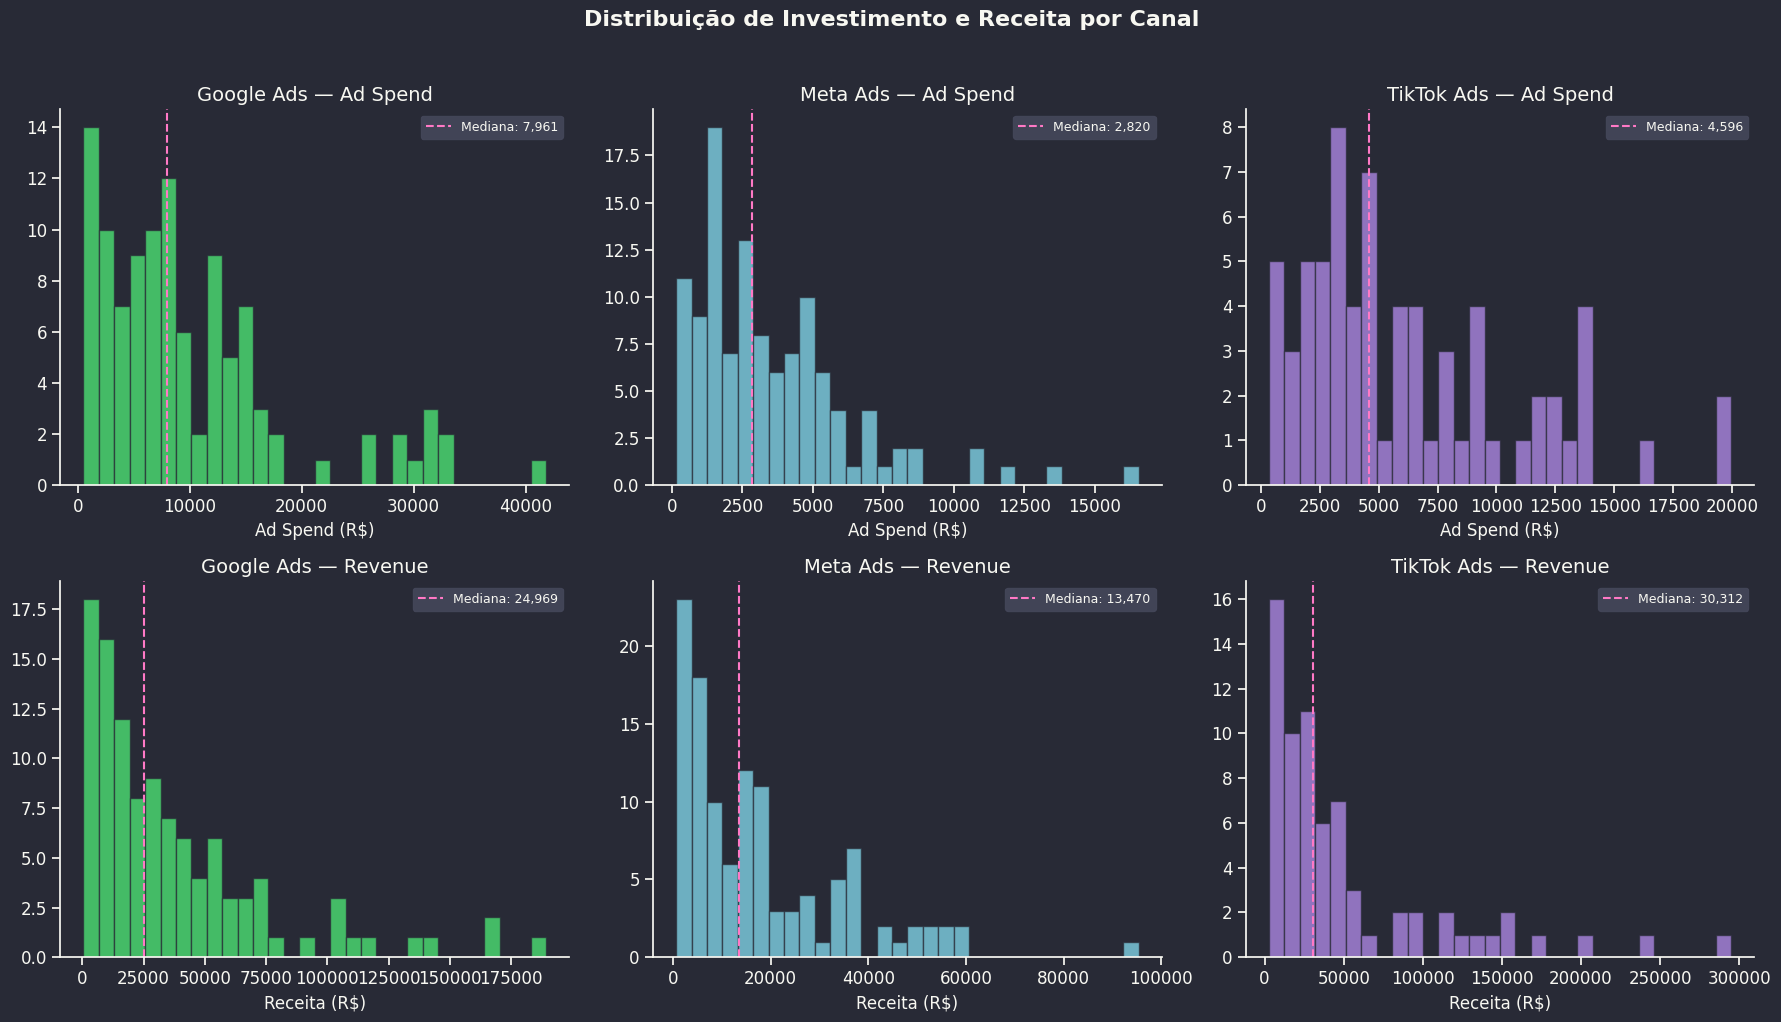

💡 Insight: Distribuições assimétricas à direita sugerem uso de transformação log nas features.


In [5]:
# === 4.2 Distribuições de Ad Spend e Revenue por Canal ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, plat in enumerate(COLORS.keys()):
    plat_data = daily[daily['platform'] == plat]

    # Ad Spend
    axes[0, i].hist(plat_data['ad_spend'], bins=30, color=COLORS[plat], alpha=0.7, edgecolor=DRACULA['bg'])
    axes[0, i].axvline(plat_data['ad_spend'].median(), color=DRACULA['pink'], linestyle='--', label=f"Mediana: {plat_data['ad_spend'].median():,.0f}")
    axes[0, i].set_title(f'{plat} — Ad Spend')
    axes[0, i].set_xlabel('Ad Spend (R$)')
    axes[0, i].legend(fontsize=9)

    # Revenue
    axes[1, i].hist(plat_data['revenue'], bins=30, color=COLORS[plat], alpha=0.7, edgecolor=DRACULA['bg'])
    axes[1, i].axvline(plat_data['revenue'].median(), color=DRACULA['pink'], linestyle='--', label=f"Mediana: {plat_data['revenue'].median():,.0f}")
    axes[1, i].set_title(f'{plat} — Revenue')
    axes[1, i].set_xlabel('Receita (R$)')
    axes[1, i].legend(fontsize=9)

plt.suptitle('Distribuição de Investimento e Receita por Canal', fontsize=16, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()
print("💡 Insight: Distribuições assimétricas à direita sugerem uso de transformação log nas features.")


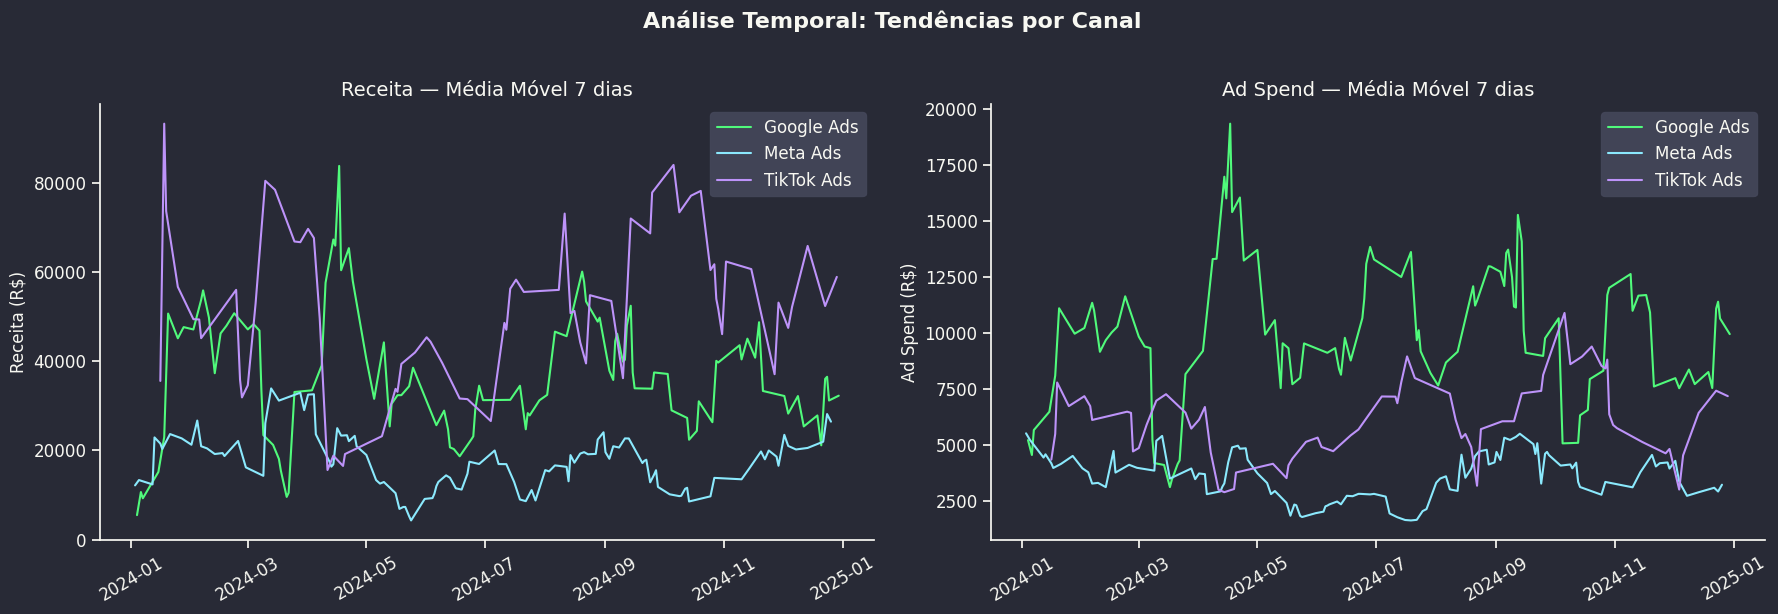

In [6]:
# === 4.3 Tendências Temporais (Séries de Receita por Canal) ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Receita semanal rolling
for plat in COLORS:
    plat_data = daily[daily['platform'] == plat].set_index('date').sort_index()
    weekly_rev = plat_data['revenue'].rolling(7, min_periods=1).mean()
    axes[0].plot(weekly_rev.index, weekly_rev, color=COLORS[plat], label=plat, linewidth=1.5)

axes[0].set_title('Receita — Média Móvel 7 dias')
axes[0].set_ylabel('Receita (R$)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# Spend semanal rolling
for plat in COLORS:
    plat_data = daily[daily['platform'] == plat].set_index('date').sort_index()
    weekly_spend = plat_data['ad_spend'].rolling(7, min_periods=1).mean()
    axes[1].plot(weekly_spend.index, weekly_spend, color=COLORS[plat], label=plat, linewidth=1.5)

axes[1].set_title('Ad Spend — Média Móvel 7 dias')
axes[1].set_ylabel('Ad Spend (R$)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Análise Temporal: Tendências por Canal', fontsize=16, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()


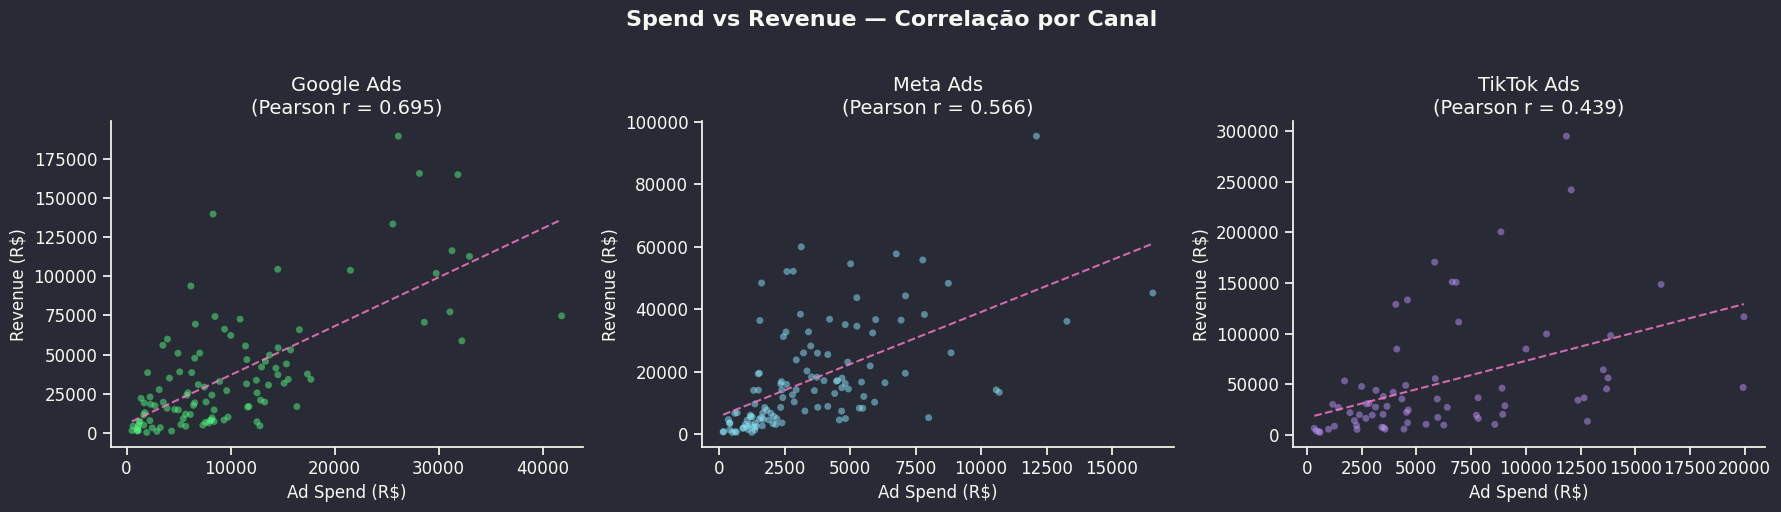

In [7]:
# === 4.4 Correlação Spend vs Revenue (Scatter + Regressão) ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, plat in enumerate(COLORS.keys()):
    plat_data = daily[daily['platform'] == plat]
    axes[i].scatter(plat_data['ad_spend'], plat_data['revenue'],
                    color=COLORS[plat], alpha=0.5, s=25, edgecolors='none')

    # Fit linear para referência visual
    z = np.polyfit(plat_data['ad_spend'], plat_data['revenue'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(plat_data['ad_spend'].min(), plat_data['ad_spend'].max(), 100)
    axes[i].plot(x_line, p(x_line), color=DRACULA['pink'], linestyle='--', linewidth=1.5, alpha=0.8)

    r = plat_data[['ad_spend', 'revenue']].corr().iloc[0, 1]
    axes[i].set_title(f'{plat}\n(Pearson r = {r:.3f})')
    axes[i].set_xlabel('Ad Spend (R$)')
    axes[i].set_ylabel('Revenue (R$)')

plt.suptitle('Spend vs Revenue — Correlação por Canal', fontsize=16, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()


In [8]:
# === 4.5 Detecção de Outliers (IQR Method — Géron) ===
print("🔍 DETECÇÃO DE OUTLIERS (Método IQR)\n")

for plat in COLORS:
    plat_data = daily[daily['platform'] == plat]
    for col in ['ad_spend', 'revenue']:
        Q1 = plat_data[col].quantile(0.25)
        Q3 = plat_data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_outliers = ((plat_data[col] < lower) | (plat_data[col] > upper)).sum()
        pct = n_outliers / len(plat_data) * 100
        flag = "⚠️" if pct > 5 else "✅"
        print(f"   {flag} {plat:12s} | {col:10s} → {n_outliers:3d} outliers ({pct:.1f}%)")

print("\n💡 Outliers serão mantidos — representam dias de alta performance real (não erros de dados).")


🔍 DETECÇÃO DE OUTLIERS (Método IQR)

   ⚠️ Google Ads   | ad_spend   →   9 outliers (8.3%)
   ⚠️ Google Ads   | revenue    →   6 outliers (5.6%)
   ✅ Meta Ads     | ad_spend   →   5 outliers (4.3%)
   ✅ Meta Ads     | revenue    →   3 outliers (2.6%)
   ✅ TikTok Ads   | ad_spend   →   2 outliers (2.9%)
   ⚠️ TikTok Ads   | revenue    →   9 outliers (13.0%)

💡 Outliers serão mantidos — representam dias de alta performance real (não erros de dados).


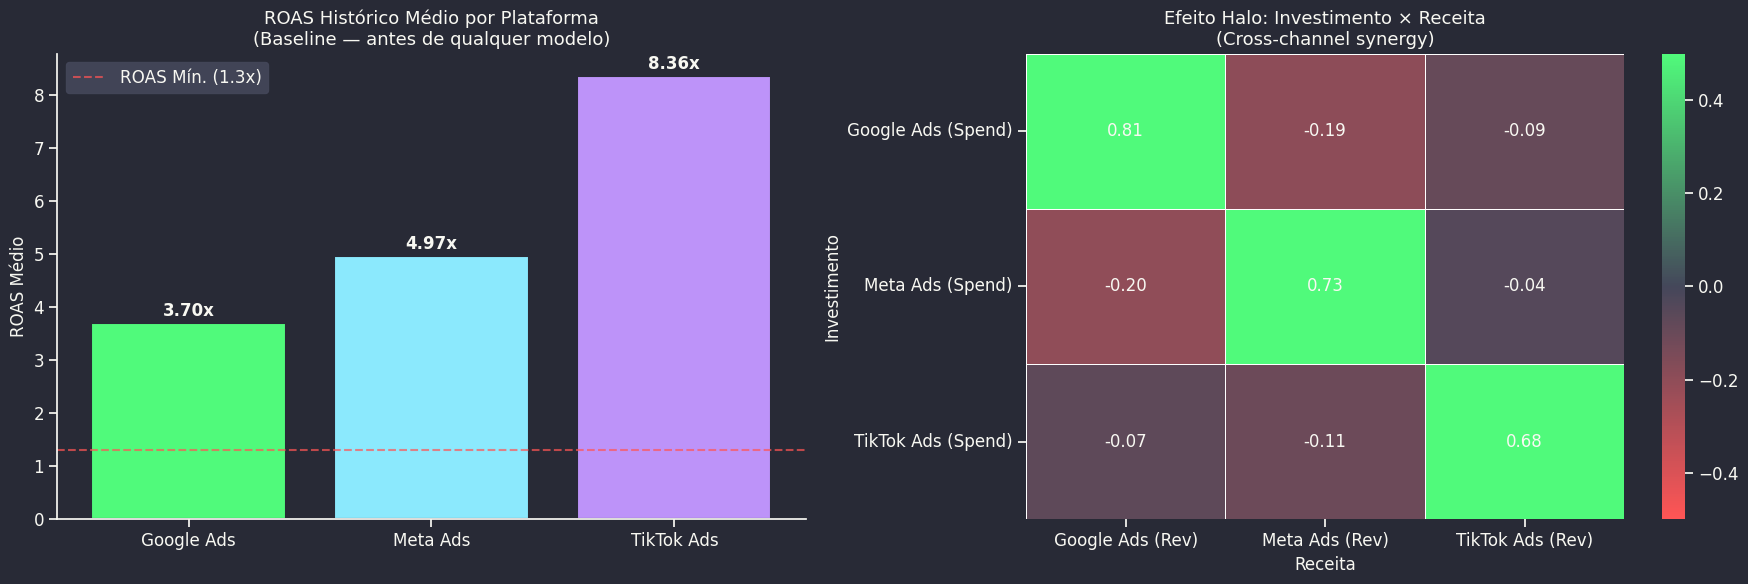

💡 Insight: Quadrados vermelhos/verdes fora da diagonal indicam sinergia (ou canibalização) entre canais.
   O Baseline (ROAS médio) será o benchmark mínimo para todos os modelos.


In [9]:
# === 4.6 Baseline (ROAS Histórico) e Efeito Halo ===
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Baseline
platform_stats_plot = daily.groupby('platform').agg(
    spend=('ad_spend', 'mean'), rev=('revenue', 'mean')
).reset_index()
platform_stats_plot['roas'] = platform_stats_plot['rev'] / platform_stats_plot['spend']

bars = axes[0].bar(platform_stats_plot['platform'], platform_stats_plot['roas'],
                   color=[COLORS[p] for p in platform_stats_plot['platform']], edgecolor=DRACULA['bg'], linewidth=1.5)
for bar, val in zip(bars, platform_stats_plot['roas']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}x', ha='center', va='bottom', fontweight='bold', fontsize=12, color=DRACULA['fg'])
axes[0].set_title('ROAS Histórico Médio por Plataforma\n(Baseline — antes de qualquer modelo)', fontsize=13)
axes[0].set_ylabel('ROAS Médio')
axes[0].axhline(y=MIN_ROAS_GLOBAL, color=DRACULA['red'], linestyle='--', alpha=0.7, label=f'ROAS Mín. ({MIN_ROAS_GLOBAL}x)')
axes[0].legend()

# Efeito Halo (Cross-channel)
pivot_spend = df.pivot_table(index='date', columns='platform', values='ad_spend', aggfunc='sum').fillna(0)
pivot_rev = df.pivot_table(index='date', columns='platform', values='revenue', aggfunc='sum').fillna(0)
pivot_spend.columns = [f"{c} (Spend)" for c in pivot_spend.columns]
pivot_rev.columns = [f"{c} (Rev)" for c in pivot_rev.columns]

cross_corr = pd.concat([pivot_spend, pivot_rev], axis=1).corr().loc[pivot_spend.columns, pivot_rev.columns]
# Heatmap com paleta Dracula
from matplotlib.colors import LinearSegmentedColormap
drac_cmap = LinearSegmentedColormap.from_list('dracula', [DRACULA['red'], DRACULA['current'], DRACULA['green']])
sns.heatmap(cross_corr, annot=True, cmap=drac_cmap, center=0, fmt=".2f",
            linewidths=0.5, ax=axes[1], vmin=-0.5, vmax=0.5,
            annot_kws={'color': DRACULA['fg']},
            cbar_kws={'label': ''})
axes[1].set_title('Efeito Halo: Investimento × Receita\n(Cross-channel synergy)', fontsize=13)
axes[1].set_xlabel('Receita')
axes[1].set_ylabel('Investimento')

plt.tight_layout()
plt.show()

print("💡 Insight: Quadrados vermelhos/verdes fora da diagonal indicam sinergia (ou canibalização) entre canais.")
print("   O Baseline (ROAS médio) será o benchmark mínimo para todos os modelos.")


<a id="5"></a>
## 5. Feature Engineering & Custom Transformers

> *"Prepare the data for Machine Learning algorithms. Write transformation pipelines."* — Géron, Cap. 2

### Custom Transformers implementados:
- **`AdstockTransformer`**: Simula o efeito carryover — o investimento de ontem ainda gera vendas hoje ($x_t' = x_t + \\alpha \\cdot x_{t-1}'$)
- **`LogSpendTransformer`**: Aplica `log1p` para linearizar a relação spend→revenue (distribuições assimétricas)

Estes transformadores seguem a API do scikit-learn (`fit`/`transform`) e se integram em `Pipeline`.


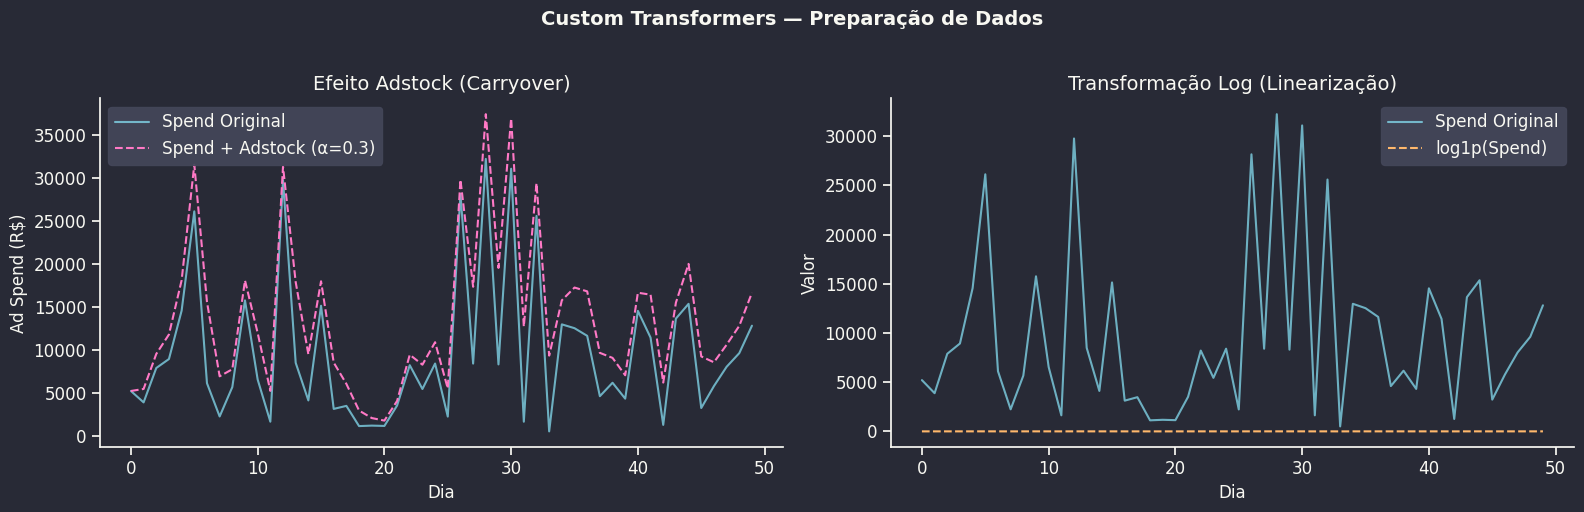

✅ Custom Transformers implementados seguindo a API do scikit-learn (fit/transform).


In [10]:
# === Custom Transformers (Géron Cap. 2: "Create custom transformers") ===

class AdstockTransformer(BaseEstimator, TransformerMixin):
    """
    Simula o efeito Adstock (carryover) de marketing.
    O investimento de ontem continua gerando receita hoje.
    x_t' = x_t + decay_rate * x_{t-1}'

    Ref: Géron Cap. 2 — Custom Transformers com fit/transform.
    """
    def __init__(self, decay_rate=0.3):
        self.decay_rate = decay_rate

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = np.zeros_like(X, dtype=float)
        X_out[0] = X[0]
        for t in range(1, len(X)):
            X_out[t] = X[t] + self.decay_rate * X_out[t - 1]
        return X_out


class LogSpendTransformer(BaseEstimator, TransformerMixin):
    """
    Aplica log1p (log(1+x)) para linearizar relações não-lineares.
    Géron: "Try various combinations of features."
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.log1p(X)


# Demonstração dos transformers
demo_spend = daily[daily['platform'] == 'Google Ads']['ad_spend'].values[:50]

adstock = AdstockTransformer(decay_rate=0.3)
demo_adstock = adstock.transform(demo_spend)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(demo_spend, label='Spend Original', alpha=0.7, color=DRACULA['cyan'])
axes[0].plot(demo_adstock, label='Spend + Adstock (α=0.3)', linestyle='--', color=DRACULA['pink'])
axes[0].set_title('Efeito Adstock (Carryover)')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Ad Spend (R$)')
axes[0].legend()

axes[1].plot(demo_spend, label='Spend Original', alpha=0.7, color=DRACULA['cyan'])
axes[1].plot(np.log1p(demo_spend), label='log1p(Spend)', linestyle='--', color=DRACULA['orange'])
axes[1].set_title('Transformação Log (Linearização)')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Valor')
axes[1].legend()

plt.suptitle('Custom Transformers — Preparação de Dados', fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

print("✅ Custom Transformers implementados seguindo a API do scikit-learn (fit/transform).")


<a id="6"></a>
## 6. Divisão Temporal dos Dados

> *"You should split your data early, before looking at it too closely."* — Géron, Cap. 2

Para dados temporais, usamos **split cronológico** (70/15/15) para evitar **data leakage** — treinar com dados futuros e testar com passado é o erro mais comum em séries temporais.

```
|=========== TREINO (70%) ===========|=== VAL (15%) ===|=== TESTE (15%) ===|
|           Jan → Ago                |    Set → Out    |    Nov → Dez      |
```


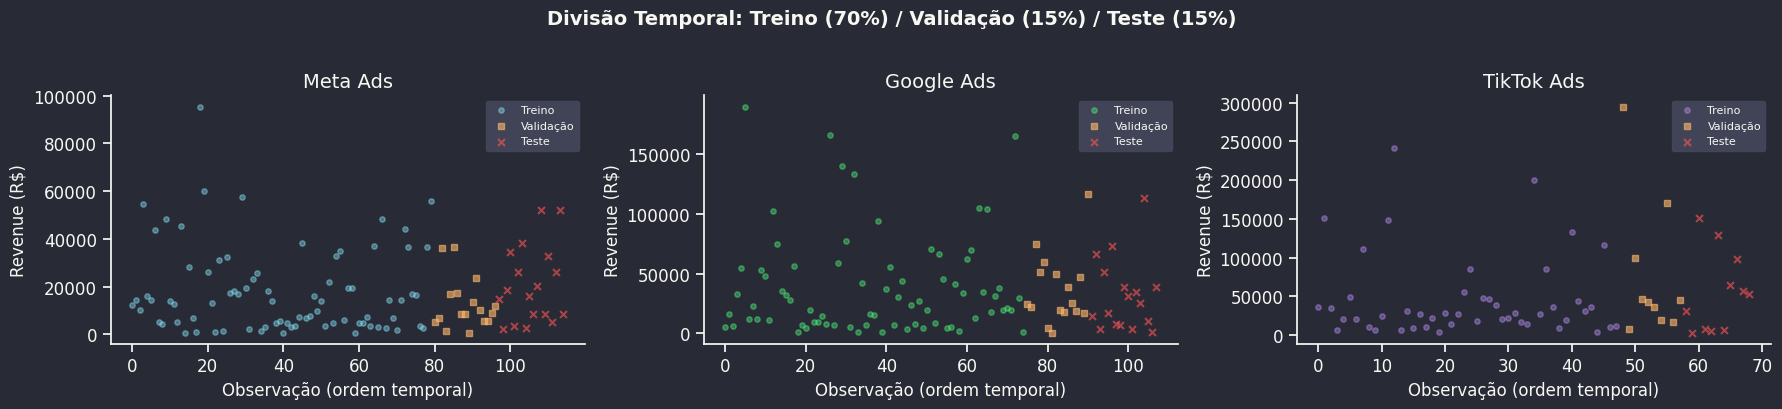

   Meta Ads     → Treino: 80 | Val: 17 | Teste: 18
   Google Ads   → Treino: 75 | Val: 16 | Teste: 17
   TikTok Ads   → Treino: 48 | Val: 10 | Teste: 11


In [11]:
# === Preparação dos dados por plataforma com split temporal ===
platforms = daily['platform'].unique()
data_by_platform = {}

for plat in platforms:
    plat_data = daily[daily['platform'] == plat].sort_values('date').reset_index(drop=True)
    n = len(plat_data)

    # Split 70/15/15 temporal
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train = plat_data.iloc[:train_end]
    val = plat_data.iloc[train_end:val_end]
    test = plat_data.iloc[val_end:]

    # Aplicar Adstock na feature de spend
    adstock = AdstockTransformer(decay_rate=0.3)
    spend_adstock = adstock.transform(plat_data['ad_spend'].values)

    data_by_platform[plat] = {
        'full': plat_data,
        'train': train,
        'val': val,
        'test': test,
        'X_train': spend_adstock[:train_end].reshape(-1, 1),
        'X_val': spend_adstock[train_end:val_end].reshape(-1, 1),
        'X_test': spend_adstock[val_end:].reshape(-1, 1),
        'y_train': train['revenue'].values,
        'y_val': val['revenue'].values,
        'y_test': test['revenue'].values,
    }

# Visualização do split temporal
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, plat in enumerate(platforms):
    d = data_by_platform[plat]
    axes[i].scatter(range(len(d['train'])), d['y_train'], c=COLORS[plat], alpha=0.4, s=15, label='Treino')
    axes[i].scatter(range(len(d['train']), len(d['train'])+len(d['val'])), d['y_val'],
                    c=DRACULA['orange'], alpha=0.6, s=25, marker='s', label='Validação')
    axes[i].scatter(range(len(d['train'])+len(d['val']), len(d['train'])+len(d['val'])+len(d['test'])), d['y_test'],
                    c=DRACULA['red'], alpha=0.6, s=25, marker='x', label='Teste')
    axes[i].set_title(f'{plat}')
    axes[i].set_xlabel('Observação (ordem temporal)')
    axes[i].set_ylabel('Revenue (R$)')
    axes[i].legend(fontsize=8)

plt.suptitle('Divisão Temporal: Treino (70%) / Validação (15%) / Teste (15%)', fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

for plat in platforms:
    d = data_by_platform[plat]
    print(f"   {plat:12s} → Treino: {len(d['train'])} | Val: {len(d['val'])} | Teste: {len(d['test'])}")


<a id="7"></a>
## 7. Modelagem Comparativa

> *"Try multiple algorithms. Don't spend too much time tweaking them. The goal is to shortlist promising models."* — Géron, Cap. 2

### Modelos comparados:

| # | Modelo | Referência (Géron) |
|---|--------|--------------------|
| 0 | **Baseline** (média) | "Always start with a simple baseline" |
| 1 | **Linear Regression** | Cap. 4 — Training Models |
| 2 | **Polynomial Regression** (grau 2) | Cap. 4 — Polynomial Regression |
| 3 | **Random Forest Regressor** | Cap. 7 — Ensemble Methods |
| 4 | **Gradient Boosting Regressor** | Cap. 7 — Boosting |
| 5 | **Curva de Saturação** ($L(1-e^{-kx})$) | Modelo de domínio (Marketing) |


In [12]:
# === Funções de Saturação (Modelo de Domínio) ===
def saturation_curve(spend, L, k):
    """Revenue = L * (1 - exp(-k * spend)). Modelo de diminishing returns."""
    return L * (1 - np.exp(-k * spend))

def marginal_roas(spend, L, k):
    """Derivada da curva de saturação: ROAS marginal."""
    return L * k * np.exp(-k * spend)

# === Custom sklearn wrapper para Curva de Saturação ===
class SaturationRegressor(BaseEstimator, RegressorMixin):
    """Wrapper sklearn para scipy.optimize.curve_fit com curva de saturação."""
    def __init__(self):
        self.L_ = None
        self.k_ = None

    def fit(self, X, y):
        x = X.ravel()
        p0 = [max(y) * 1.5, 0.0001]
        bounds = (0, [np.inf, 1])
        try:
            popt, _ = curve_fit(saturation_curve, x, y, p0=p0, bounds=bounds, maxfev=10000)
            self.L_, self.k_ = popt
        except RuntimeError:
            self.L_, self.k_ = max(y), 0.0001
        return self

    def predict(self, X):
        return saturation_curve(X.ravel(), self.L_, self.k_)


# === Treinar todos os modelos para cada plataforma ===
results = []
trained_models = {}

for plat in platforms:
    d = data_by_platform[plat]
    X_tr, y_tr = d['X_train'], d['y_train']
    X_val, y_val = d['X_val'], d['y_val']
    trained_models[plat] = {}

    models = {
        'Baseline (Média)': None,
        'Linear Regression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
        'Polynomial (grau 2)': Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)),
                                          ('scaler', StandardScaler()),
                                          ('lr', LinearRegression())]),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED, max_depth=3),
        'Curva de Saturação': SaturationRegressor(),
    }

    for name, model in models.items():
        t0 = time.time()

        if name == 'Baseline (Média)':
            y_pred_val = np.full_like(y_val, y_tr.mean(), dtype=float)
            elapsed = time.time() - t0
        else:
            model.fit(X_tr, y_tr)
            y_pred_val = model.predict(X_val)
            elapsed = time.time() - t0
            trained_models[plat][name] = model

        # Clamp negativo para zero (receita não pode ser negativa)
        y_pred_val = np.maximum(y_pred_val, 0)

        r2 = r2_score(y_val, y_pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)
        mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100

        results.append({
            'Plataforma': plat,
            'Modelo': name,
            'R²': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE (%)': mape,
            'Tempo (s)': elapsed,
        })

# Tabela de resultados
results_df = pd.DataFrame(results)
print("=" * 90)
print("📊 COMPARAÇÃO DE MODELOS — Validação")
print("=" * 90)

for plat in platforms:
    print(f"\n{'─'*90}")
    print(f"  {plat}")
    print(f"{'─'*90}")
    plat_results = results_df[results_df['Plataforma'] == plat].sort_values('R²', ascending=False)
    display(plat_results[['Modelo', 'R²', 'RMSE', 'MAE', 'MAPE (%)', 'Tempo (s)']].reset_index(drop=True))

# Identificar melhor modelo por plataforma
best_models = {}
for plat in platforms:
    plat_results = results_df[
        (results_df['Plataforma'] == plat) &
        (results_df['Modelo'] != 'Baseline (Média)')
    ]
    best_name = plat_results.sort_values('R²', ascending=False).iloc[0]['Modelo']
    best_models[plat] = best_name
    print(f"\n🏆 {plat}: Melhor modelo → {best_name}")


📊 COMPARAÇÃO DE MODELOS — Validação

──────────────────────────────────────────────────────────────────────────────────────────
  Meta Ads
──────────────────────────────────────────────────────────────────────────────────────────


,Modelo,R²,RMSE,MAE,MAPE (%),Tempo (s)
0,Baseline (Média),-0.261319,11557.449430,10245.301691,298.957021,0.000128
1,Curva de Saturação,-0.892651,14157.440055,11720.009593,273.569745,0.015883
2,Linear Regression,-0.929927,14296.178268,11627.000711,263.103946,0.021044
3,Polynomial (grau 2),-0.953683,14383.895452,11763.887687,267.321818,0.006084
4,Random Forest,-2.109797,18147.444193,14750.021159,231.176717,0.195431
5,Gradient Boosting,-3.436080,21674.501994,16251.727055,254.130187,0.066573



──────────────────────────────────────────────────────────────────────────────────────────
  Google Ads
──────────────────────────────────────────────────────────────────────────────────────────


,Modelo,R²,RMSE,MAE,MAPE (%),Tempo (s)
0,Curva de Saturação,0.511562,19934.300918,14251.292908,162.967746,0.303300
1,Random Forest,0.436782,21405.954309,15906.061206,111.216463,0.195000
2,Gradient Boosting,0.352673,22948.697141,16786.221559,107.224290,0.061006
3,Linear Regression,0.298516,23889.404134,16329.379120,62.101279,0.001818
4,Polynomial (grau 2),0.020251,28232.783874,18144.584953,129.465106,0.002342
5,Baseline (Média),-0.004633,28589.066908,22816.579350,653.131673,0.000026



──────────────────────────────────────────────────────────────────────────────────────────
  TikTok Ads
──────────────────────────────────────────────────────────────────────────────────────────


,Modelo,R²,RMSE,MAE,MAPE (%),Tempo (s)
0,Curva de Saturação,-0.017354,86384.240062,62996.916817,138.198719,0.353969
1,Linear Regression,-0.021551,86562.232535,63180.422821,137.544813,0.001814
2,Baseline (Média),-0.141986,91522.705455,53603.784375,107.997922,0.000021
3,Polynomial (grau 2),-0.181539,93094.175226,66553.360034,134.752263,0.002549
4,Random Forest,-0.213386,94340.441780,61619.512190,128.787423,0.194929
5,Gradient Boosting,-0.472536,103927.730993,67138.363362,109.676867,0.059270



🏆 Meta Ads: Melhor modelo → Curva de Saturação

🏆 Google Ads: Melhor modelo → Curva de Saturação

🏆 TikTok Ads: Melhor modelo → Curva de Saturação


<a id="8"></a>
## 8. Validação Cruzada Temporal

> *"Cross-validation allows you to get not just an estimate of the performance, but also a measure of how precise this estimate is."* — Géron, Cap. 2

Usamos `TimeSeriesSplit` (5 folds) para respeitar a ordem temporal e evitar data leakage.


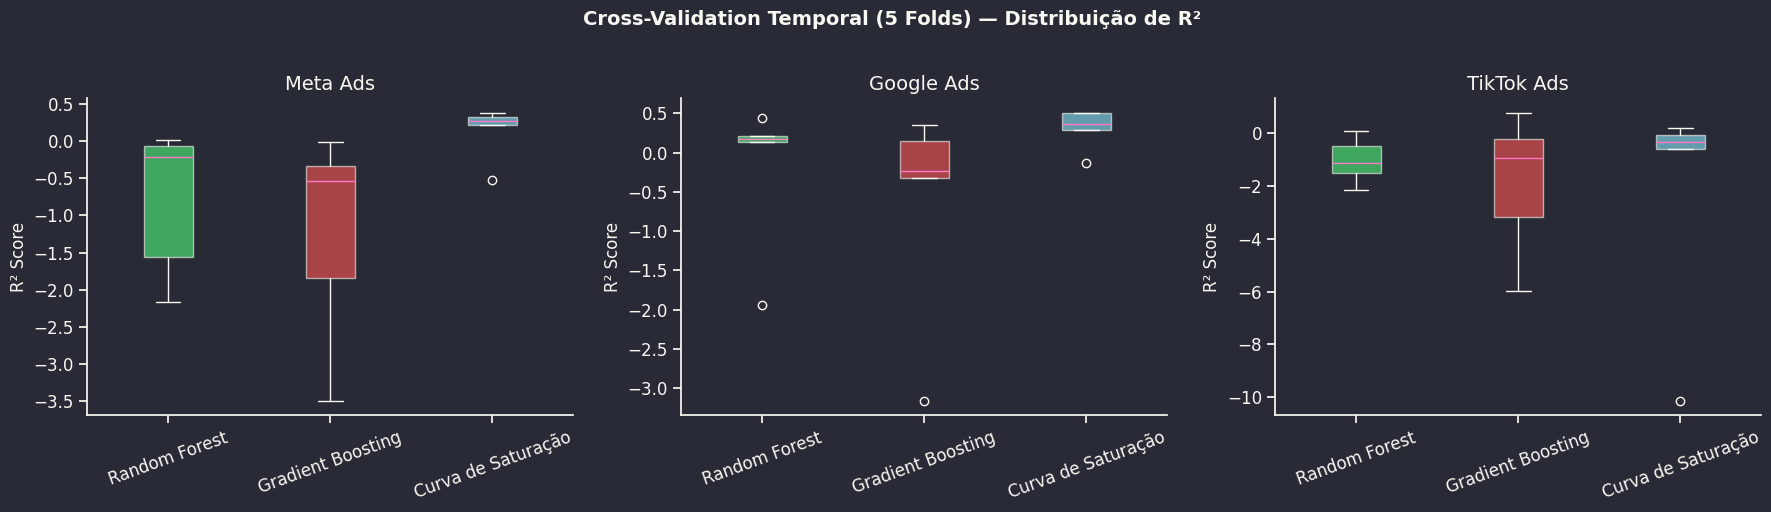


📊 Resultados da Validação Cruzada Temporal:
   Meta Ads     | Random Forest             → R² = -0.796 ± 0.893
   Meta Ads     | Gradient Boosting         → R² = -1.247 ± 1.285
   Meta Ads     | Curva de Saturação        → R² = 0.137 ± 0.333
   Google Ads   | Random Forest             → R² = -0.192 ± 0.880
   Google Ads   | Gradient Boosting         → R² = -0.643 ± 1.283
   Google Ads   | Curva de Saturação        → R² = 0.308 ± 0.236
   TikTok Ads   | Random Forest             → R² = -1.052 ± 0.776
   TikTok Ads   | Gradient Boosting         → R² = -1.924 ± 2.407
   TikTok Ads   | Curva de Saturação        → R² = -2.197 ± 3.975


In [13]:
# === Cross-Validation Temporal com TimeSeriesSplit ===
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

for plat in platforms:
    d = data_by_platform[plat]
    # Usar treino + validação para CV
    X_cv = np.vstack([d['X_train'], d['X_val']])
    y_cv = np.concatenate([d['y_train'], d['y_val']])

    # Testar apenas o melhor modelo + Saturação
    models_cv = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED, max_depth=3),
        'Curva de Saturação': SaturationRegressor(),
    }

    for name, model in models_cv.items():
        fold_scores = []
        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv)):
            model_clone = __import__('sklearn.base', fromlist=['clone']).clone(model)
            model_clone.fit(X_cv[train_idx], y_cv[train_idx])
            y_pred = np.maximum(model_clone.predict(X_cv[val_idx]), 0)
            fold_scores.append(r2_score(y_cv[val_idx], y_pred))

        cv_results.append({
            'Plataforma': plat,
            'Modelo': name,
            'R² Médio': np.mean(fold_scores),
            'R² Std': np.std(fold_scores),
            'Folds': fold_scores,
        })

# Visualização dos resultados de CV
cv_df = pd.DataFrame(cv_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, plat in enumerate(platforms):
    plat_cv = cv_df[cv_df['Plataforma'] == plat]
    data_to_plot = [row['Folds'] for _, row in plat_cv.iterrows()]
    labels = plat_cv['Modelo'].tolist()

    bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], [DRACULA['green'], DRACULA['red'], DRACULA['cyan']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(f'{plat}')
    axes[i].set_ylabel('R² Score')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Cross-Validation Temporal (5 Folds) — Distribuição de R²', fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

print("\n📊 Resultados da Validação Cruzada Temporal:")
for _, row in cv_df.iterrows():
    print(f"   {row['Plataforma']:12s} | {row['Modelo']:25s} → R² = {row['R² Médio']:.3f} ± {row['R² Std']:.3f}")


<a id="9"></a>
## 9. Hyperparameter Tuning

> *"Once you have a shortlist of promising models, you need to fine-tune them. One way to do that is to fiddle with the hyperparameters manually... A much better option is to use Scikit-Learn's GridSearchCV."* — Géron, Cap. 2

Realizamos **GridSearchCV** com `TimeSeriesSplit` (5 folds) para otimizar os dois melhores modelos ensemble: **Random Forest** e **Gradient Boosting**. O uso do `TimeSeriesSplit` garante que não haja *data leakage* temporal durante o tuning.

| Modelo | Hiperparâmetros Otimizados |
|--------|---------------------------|
| **Random Forest** | `n_estimators`, `max_depth`, `min_samples_leaf` |
| **Gradient Boosting** | `n_estimators`, `max_depth`, `learning_rate` |

🔧 HYPERPARAMETER TUNING

📊 Meta Ads:
   Random Forest             → CV R²: 0.0039 | Test R²: 0.0073 (Δ = +0.0818)
                               Params: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
   Gradient Boosting         → CV R²: -0.0134 | Test R²: 0.0103 (Δ = +0.1815)
                               Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}

📊 Google Ads:
   Random Forest             → CV R²: 0.1284 | Test R²: 0.4395 (Δ = +0.4023)
                               Params: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 100}
   Gradient Boosting         → CV R²: 0.1938 | Test R²: 0.2866 (Δ = +0.3348)
                               Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}

📊 TikTok Ads:
   Random Forest             → CV R²: -0.6884 | Test R²: -0.6914 (Δ = -0.2891)
                               Params: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 50}
   Gradient Boosting         → CV R²: -1.3621 |

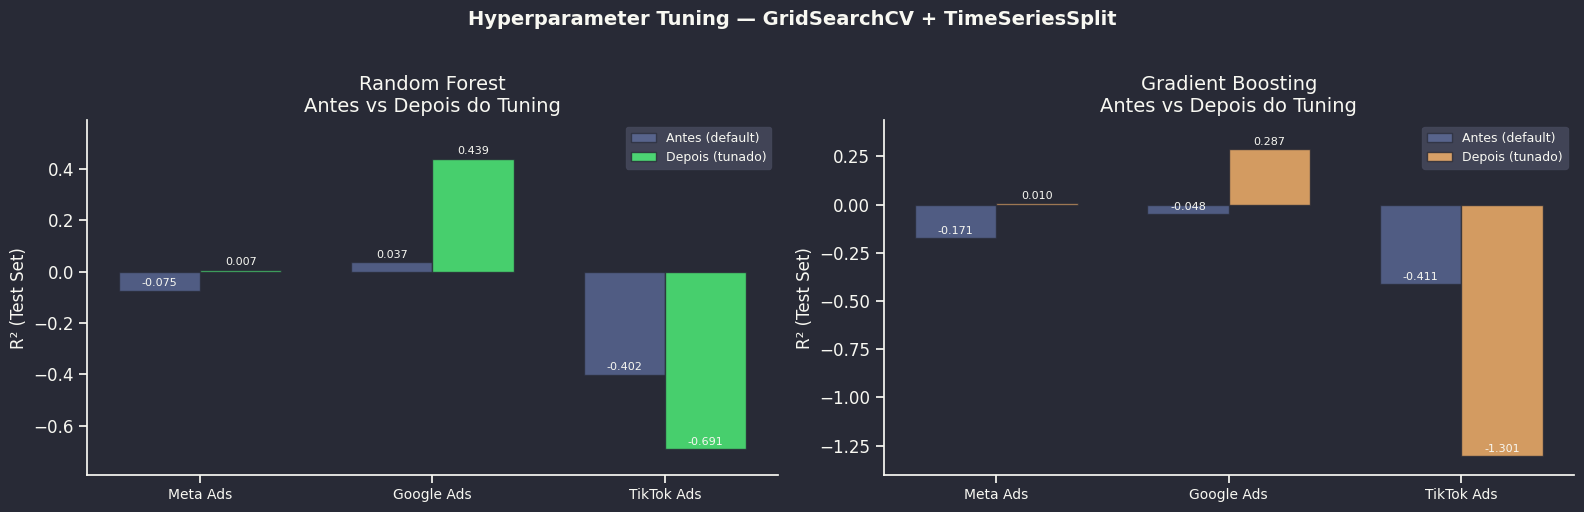

In [14]:
# === Hyperparameter Tuning com GridSearchCV + TimeSeriesSplit (Géron Cap. 2) ===
tscv_tuning = TimeSeriesSplit(n_splits=5)

# Grids de hiperparâmetros
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 10, None],
        'min_samples_leaf': [1, 5, 10],
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'max_depth': [2, 3, 5],
        'learning_rate': [0.01, 0.1, 0.2],
    },
}

tuning_results = []
tuned_models = {}

print("\U0001f527 HYPERPARAMETER TUNING")
print("=" * 70)

for plat in platforms:
    d = data_by_platform[plat]
    X_tune = np.vstack([d['X_train'], d['X_val']])
    y_tune = np.concatenate([d['y_train'], d['y_val']])
    tuned_models[plat] = {}
    print(f"\n\U0001f4ca {plat}:")

    for model_name, param_grid in param_grids.items():
        if model_name == 'Random Forest':
            base = RandomForestRegressor(random_state=SEED, n_jobs=-1)
        else:
            base = GradientBoostingRegressor(random_state=SEED)

        t0 = time.time()
        gs = GridSearchCV(
            base, param_grid,
            cv=tscv_tuning,
            scoring='r2',
            n_jobs=-1,
            refit=True,
        )
        gs.fit(X_tune, y_tune)
        elapsed = time.time() - t0

        tuned_models[plat][model_name] = gs.best_estimator_

        # Score no conjunto de teste com modelo original (antes do tuning)
        old_model = trained_models[plat].get(model_name)
        if old_model is not None:
            old_pred = np.maximum(old_model.predict(d['X_test']), 0)
            old_score = r2_score(d['y_test'], old_pred)
        else:
            old_score = None

        # Score no conjunto de teste com modelo tunado
        new_pred = np.maximum(gs.best_estimator_.predict(d['X_test']), 0)
        new_score = r2_score(d['y_test'], new_pred)
        delta = f"(Δ = {new_score - old_score:+.4f})" if old_score is not None else ""

        tuning_results.append({
            'Plataforma': plat,
            'Modelo': model_name,
            'R² Antes': old_score,
            'Best R² (CV)': gs.best_score_,
            'R² Depois': new_score,
            'Best Params': gs.best_params_,
            'Tempo (s)': elapsed,
        })

        print(f"   {model_name:25s} → CV R²: {gs.best_score_:.4f} | Test R²: {new_score:.4f} {delta}")
        print(f"   {'':25s}   Params: {gs.best_params_}")

# Atualizar trained_models com os modelos tunados
for plat in platforms:
    for model_name in tuned_models[plat]:
        trained_models[plat][model_name] = tuned_models[plat][model_name]

# Tabela de comparação
tuning_df = pd.DataFrame(tuning_results)
print("\n" + "=" * 70)
print("\U0001f4ca COMPARAÇÃO ANTES vs DEPOIS DO TUNING")
print("=" * 70)
for _, row in tuning_df.iterrows():
    before = f"{row['R² Antes']:.4f}" if row['R² Antes'] is not None else "N/A"
    after = f"{row['R² Depois']:.4f}"
    print(f"   {row['Plataforma']:12s} | {row['Modelo']:25s} | Antes: {before} → Depois: {after}")

# Visualização: Antes vs Depois do Tuning
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, model_name in enumerate(['Random Forest', 'Gradient Boosting']):
    model_df = tuning_df[tuning_df['Modelo'] == model_name]
    x = np.arange(len(platforms))
    width = 0.35

    before_scores = model_df['R² Antes'].astype(float).values
    after_scores = model_df['R² Depois'].astype(float).values

    bars1 = axes[idx].bar(x - width/2, before_scores, width, label='Antes (default)',
                          color=DRACULA['comment'], alpha=0.7, edgecolor=DRACULA['bg'])
    bars2 = axes[idx].bar(x + width/2, after_scores, width, label='Depois (tunado)',
                          color=DRACULA['green'] if idx == 0 else DRACULA['orange'],
                          alpha=0.8, edgecolor=DRACULA['bg'])

    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(platforms, fontsize=10)
    axes[idx].set_ylabel('R² (Test Set)')
    axes[idx].set_title(f'{model_name}\nAntes vs Depois do Tuning')
    axes[idx].legend(fontsize=9)
    axes[idx].set_ylim([min(0, min(before_scores.min(), after_scores.min()) - 0.1),
                        max(before_scores.max(), after_scores.max()) + 0.15])

    # Valores nas barras
    for bar in bars1:
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                      f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color=DRACULA['fg'])
    for bar in bars2:
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                      f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color=DRACULA['fg'])

plt.suptitle('Hyperparameter Tuning — GridSearchCV + TimeSeriesSplit',
             fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

<a id="10"></a>
## 10. Análise de Erros, Diagnóstico e Learning Curves

> *"Before you try to improve your model, look at the types of errors it makes."* — Géron, Cap. 3

### Diagnósticos:
- **Predicted vs Actual** — O quão bem o modelo prediz?
- **Distribuição de resíduos** — São normais? (esperamos que sim)
- **QQ-Plot** — Validação gráfica da normalidade dos resíduos
- **Curvas de Aprendizado** — Diagnóstico de Bias vs Variância (Géron Cap. 4)

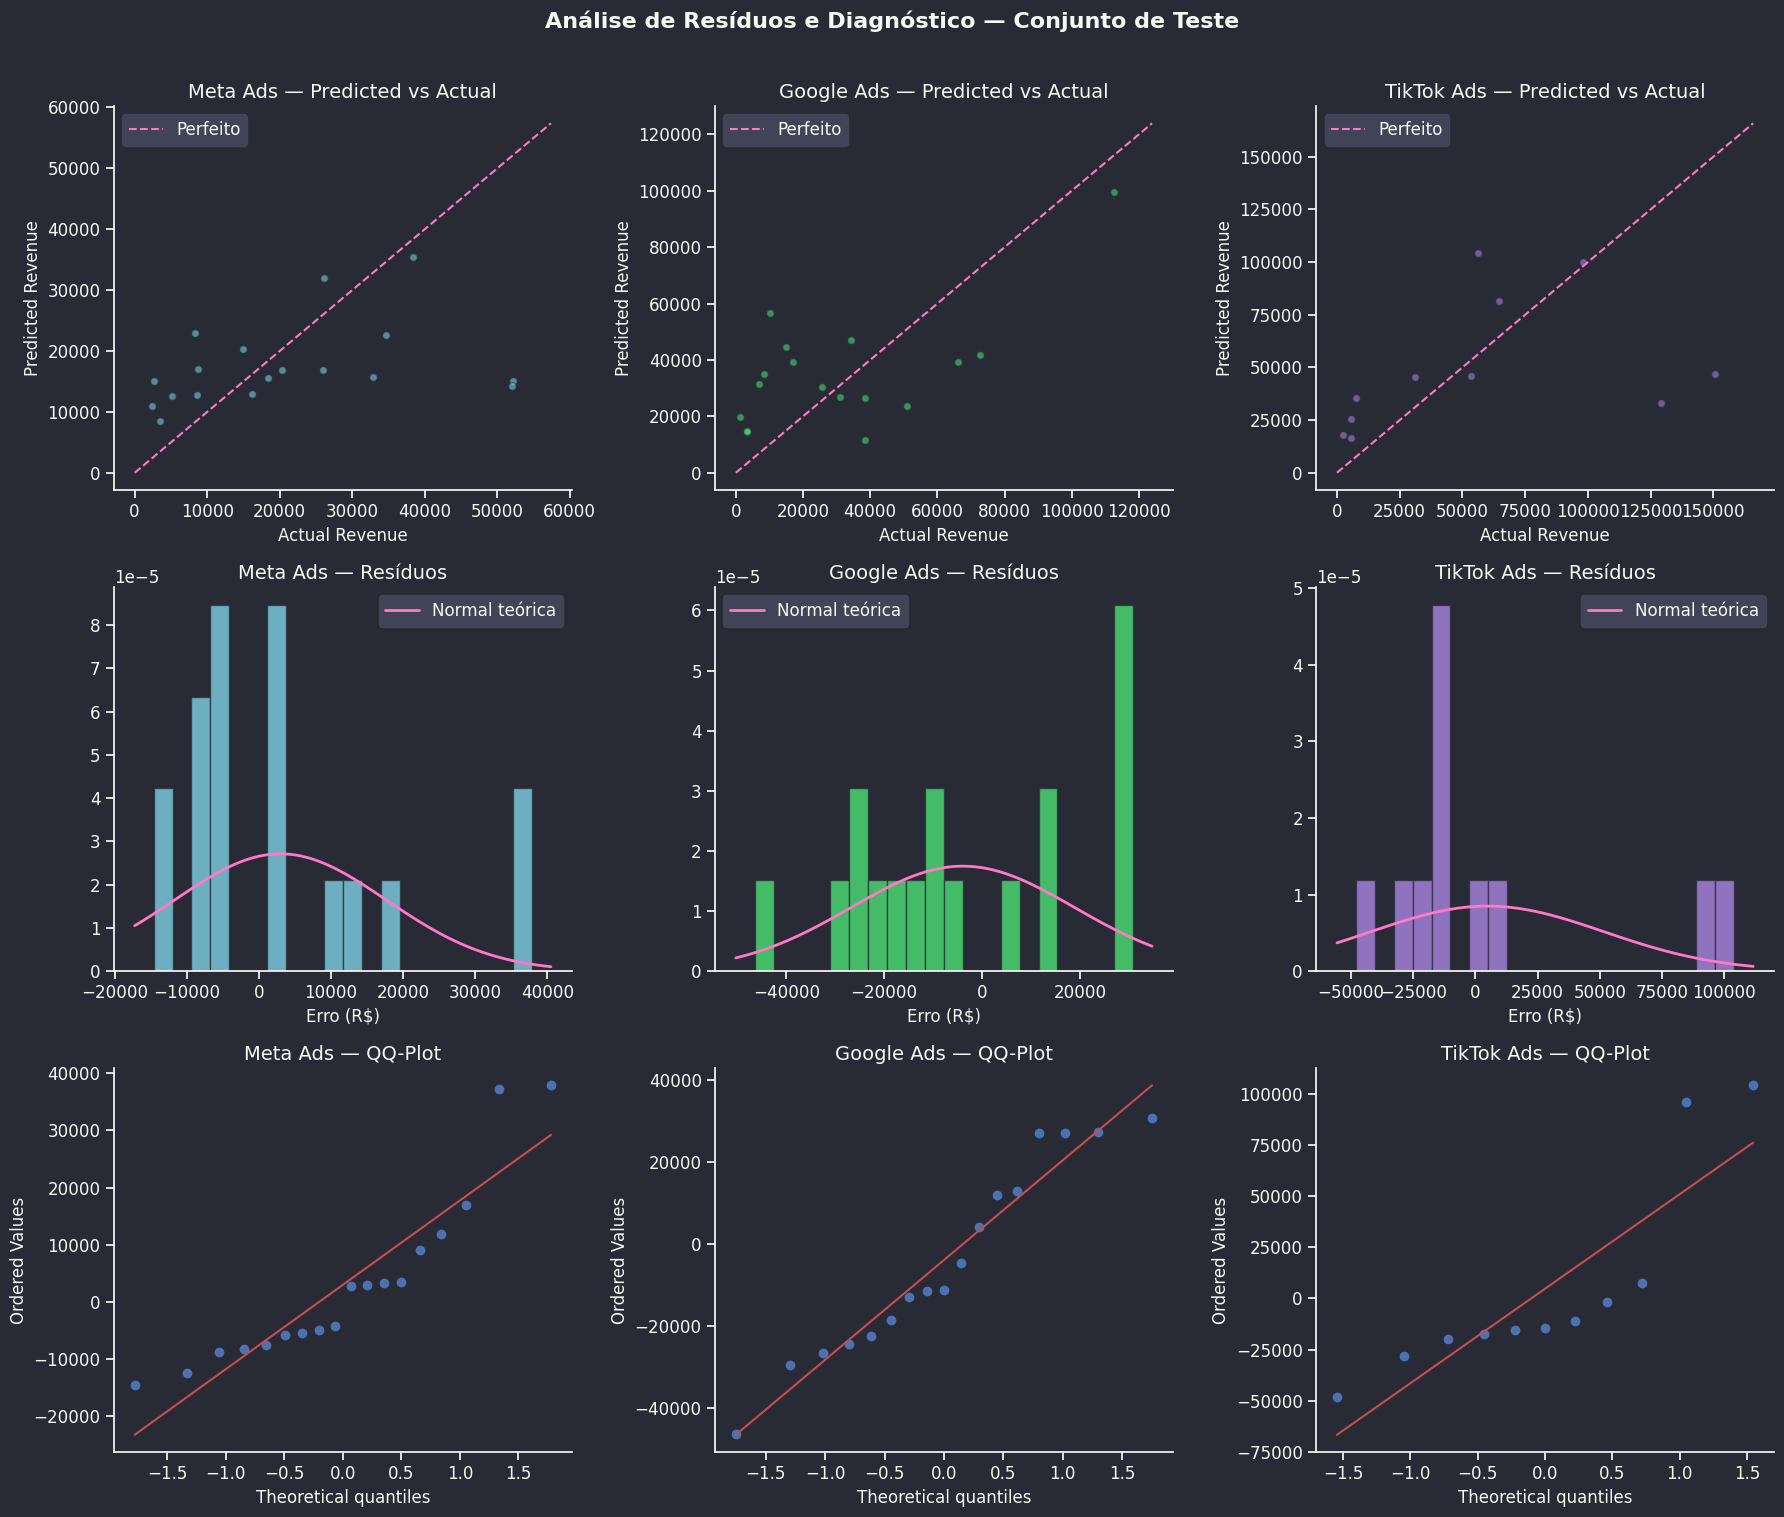


📈 Curvas de Aprendizado (Learning Curves):


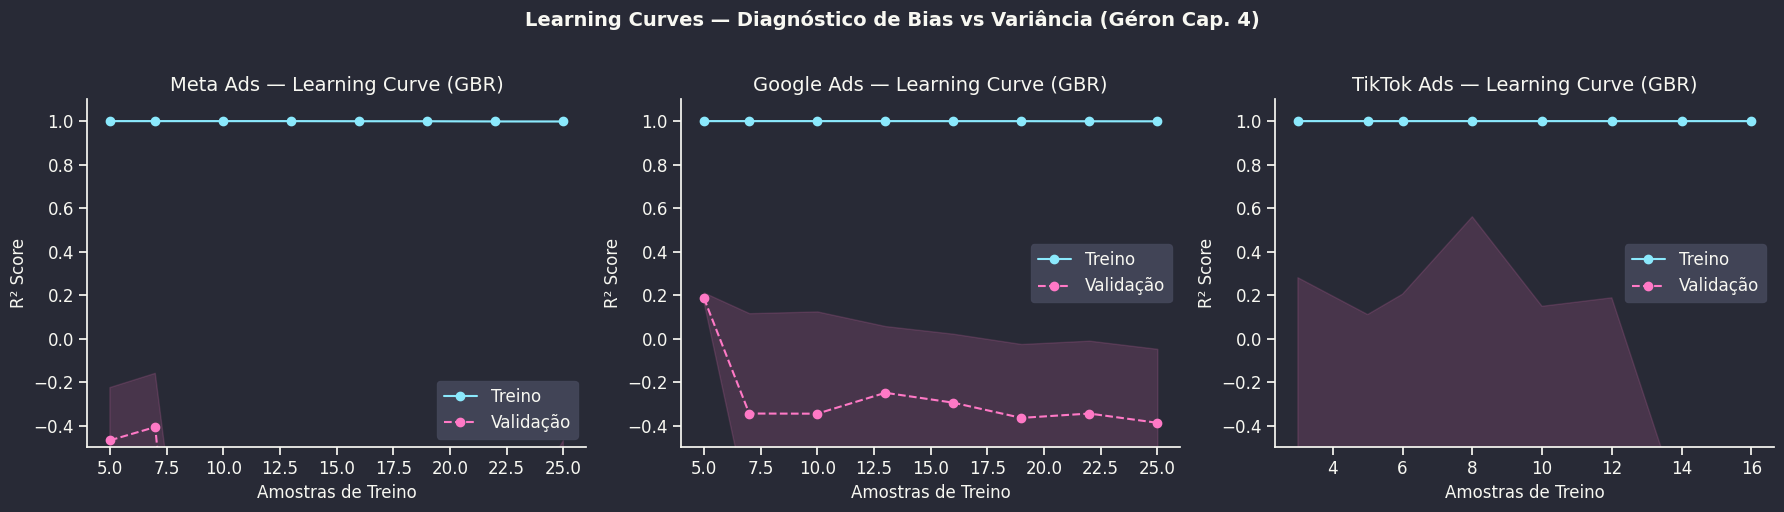

💡 Gap grande entre treino e validação → Overfitting. Convergência → modelo bem ajustado.


In [15]:
# === Análise de Resíduos e Curvas de Aprendizado ===
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for i, plat in enumerate(platforms):
    d = data_by_platform[plat]

    # Usar curva de saturação como modelo principal para otimização
    sat_model = SaturationRegressor()
    X_full = np.vstack([d['X_train'], d['X_val']])
    y_full = np.concatenate([d['y_train'], d['y_val']])
    sat_model.fit(X_full, y_full)

    y_pred_test = np.maximum(sat_model.predict(d['X_test']), 0)
    residuals = d['y_test'] - y_pred_test

    # 1. Predicted vs Actual
    max_val = max(d['y_test'].max(), y_pred_test.max()) * 1.1
    axes[0, i].scatter(d['y_test'], y_pred_test, alpha=0.5, color=COLORS[plat], s=30, edgecolors=DRACULA['bg'])
    axes[0, i].plot([0, max_val], [0, max_val], color=DRACULA['pink'], linestyle='--', linewidth=1.5, label='Perfeito')
    axes[0, i].set_title(f'{plat} — Predicted vs Actual')
    axes[0, i].set_xlabel('Actual Revenue')
    axes[0, i].set_ylabel('Predicted Revenue')
    axes[0, i].legend()

    # 2. Distribuição de resíduos
    axes[1, i].hist(residuals, bins=20, color=COLORS[plat], alpha=0.7, edgecolor=DRACULA['bg'], density=True)
    xmin, xmax = axes[1, i].get_xlim()
    x_kde = np.linspace(xmin, xmax, 100)
    if np.std(residuals) > 0:
        axes[1, i].plot(x_kde, stats.norm.pdf(x_kde, np.mean(residuals), np.std(residuals)),
                       color=DRACULA['pink'], linestyle='-', linewidth=2, label='Normal teórica')
    axes[1, i].set_title(f'{plat} — Resíduos')
    axes[1, i].set_xlabel('Erro (R$)')
    axes[1, i].legend()

    # 3. QQ-Plot
    stats.probplot(residuals, plot=axes[2, i])
    axes[2, i].set_title(f'{plat} — QQ-Plot')

plt.suptitle('Análise de Resíduos e Diagnóstico — Conjunto de Teste',
             fontsize=16, fontweight='bold', y=1.01, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

# Learning Curves (Géron Cap. 4)
print("\n📈 Curvas de Aprendizado (Learning Curves):")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, plat in enumerate(platforms):
    d = data_by_platform[plat]
    X_lc = np.vstack([d['X_train'], d['X_val']])
    y_lc = np.concatenate([d['y_train'], d['y_val']])

    model_lc = GradientBoostingRegressor(n_estimators=100, random_state=SEED, max_depth=3)
    train_sizes, train_scores, val_scores = learning_curve(
        model_lc, X_lc, y_lc, cv=TimeSeriesSplit(n_splits=3),
        train_sizes=np.linspace(0.2, 1.0, 8), scoring='r2', n_jobs=-1
    )

    axes[i].plot(train_sizes, train_scores.mean(axis=1), 'o-', color=DRACULA['cyan'], label='Treino')
    axes[i].fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                         train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color=DRACULA['cyan'])
    axes[i].plot(train_sizes, val_scores.mean(axis=1), 'o--', color=DRACULA['pink'], label='Validação')
    axes[i].fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                         val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color=DRACULA['pink'])
    axes[i].set_title(f'{plat} — Learning Curve (GBR)')
    axes[i].set_xlabel('Amostras de Treino')
    axes[i].set_ylabel('R² Score')
    axes[i].legend()
    axes[i].set_ylim(-0.5, 1.1)

plt.suptitle('Learning Curves — Diagnóstico de Bias vs Variância (Géron Cap. 4)',
             fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()
print("💡 Gap grande entre treino e validação → Overfitting. Convergência → modelo bem ajustado.")


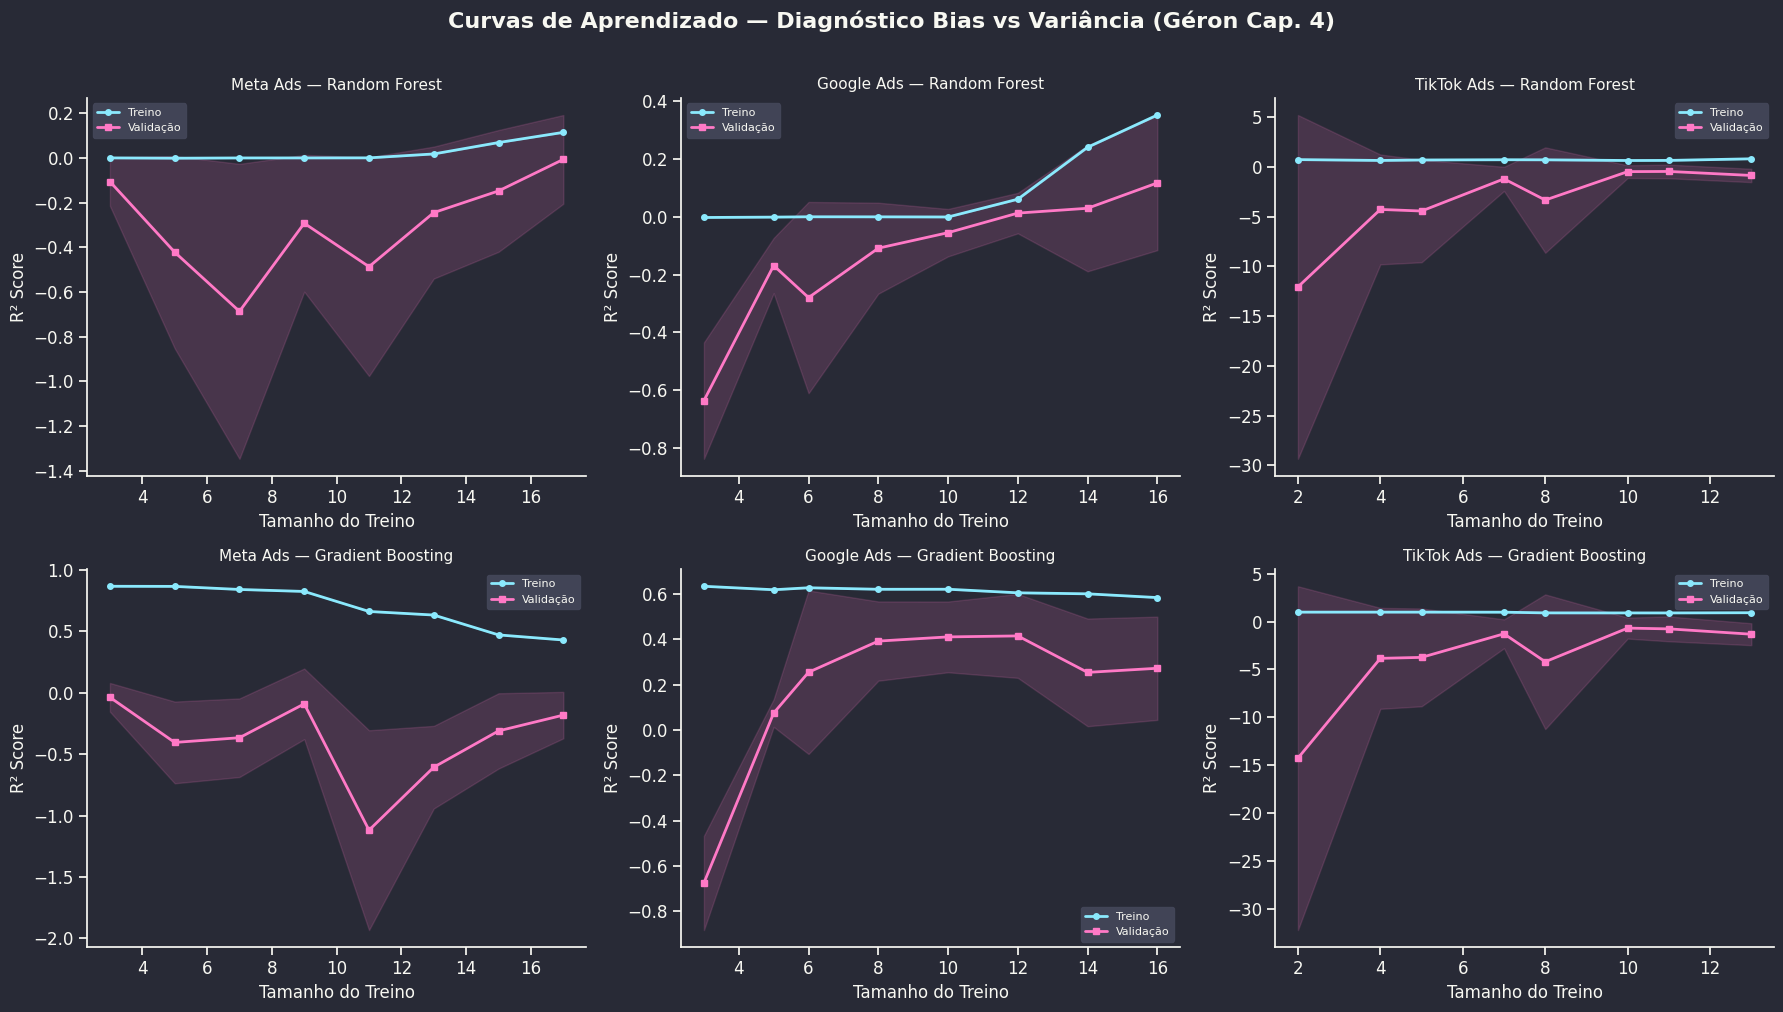

📖 Interpretação das Learning Curves:
   • Se Treino ≈ Validação (ambos altos):  ✅ Bom ajuste (modelo generaliza bem)
   • Se Treino >> Validação:                ⚠️ Overfitting (variância alta → mais dados ou regularização)
   • Se Treino ≈ Validação (ambos baixos):  ⚠️ Underfitting (bias alto → modelo mais complexo)


In [16]:
# === Curvas de Aprendizado (Learning Curves — Géron Cap. 4) ===
# Diagnóstico: Bias alto (underfitting) vs Variância alta (overfitting)
from sklearn.base import clone

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

model_configs = [
    ('Random Forest', DRACULA['green']),
    ('Gradient Boosting', DRACULA['orange']),
]

for j, (name, color) in enumerate(model_configs):
    for i, plat in enumerate(platforms):
        d = data_by_platform[plat]
        X_lc = np.vstack([d['X_train'], d['X_val']])
        y_lc = np.concatenate([d['y_train'], d['y_val']])

        model = clone(trained_models[plat][name])

        train_sizes, train_scores, val_scores = learning_curve(
            model, X_lc, y_lc,
            cv=TimeSeriesSplit(n_splits=5),
            train_sizes=np.linspace(0.2, 1.0, 8),
            scoring='r2',
            n_jobs=-1,
        )

        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        val_mean = val_scores.mean(axis=1)
        val_std = val_scores.std(axis=1)

        axes[j, i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                                alpha=0.15, color=DRACULA['cyan'])
        axes[j, i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                                alpha=0.15, color=DRACULA['pink'])
        axes[j, i].plot(train_sizes, train_mean, 'o-', color=DRACULA['cyan'],
                        label='Treino', markersize=4, linewidth=2)
        axes[j, i].plot(train_sizes, val_mean, 's-', color=DRACULA['pink'],
                        label='Validação', markersize=4, linewidth=2)
        axes[j, i].set_title(f'{plat} — {name}', fontsize=11)
        axes[j, i].set_xlabel('Tamanho do Treino')
        axes[j, i].set_ylabel('R² Score')
        axes[j, i].legend(fontsize=8)

plt.suptitle('Curvas de Aprendizado — Diagnóstico Bias vs Variância (Géron Cap. 4)',
             fontsize=16, fontweight='bold', y=1.01, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

print("\U0001f4d6 Interpretação das Learning Curves:")
print("   • Se Treino ≈ Validação (ambos altos):  ✅ Bom ajuste (modelo generaliza bem)")
print("   • Se Treino >> Validação:                ⚠️ Overfitting (variância alta → mais dados ou regularização)")
print("   • Se Treino ≈ Validação (ambos baixos):  ⚠️ Underfitting (bias alto → modelo mais complexo)")

<a id="11"></a>
## 11. Feature Importance & Interpretabilidade

> *"Random Forests make it easy to measure the relative importance of each feature."* — Géron, Cap. 7

### Análises de Interpretabilidade:
- **Permutation Importance** — Impacto da feature `ad_spend` em cada canal (Géron Cap. 7)
- **Curvas de Resposta** — Comparação das curvas de saturação entre canais
- **ROAS Marginal** — Retorno marginal decrescente por canal (ponto de saturação)
- **Elasticidade** — Sensibilidade da receita ao investimento ($\varepsilon < 1$ → região de saturação)

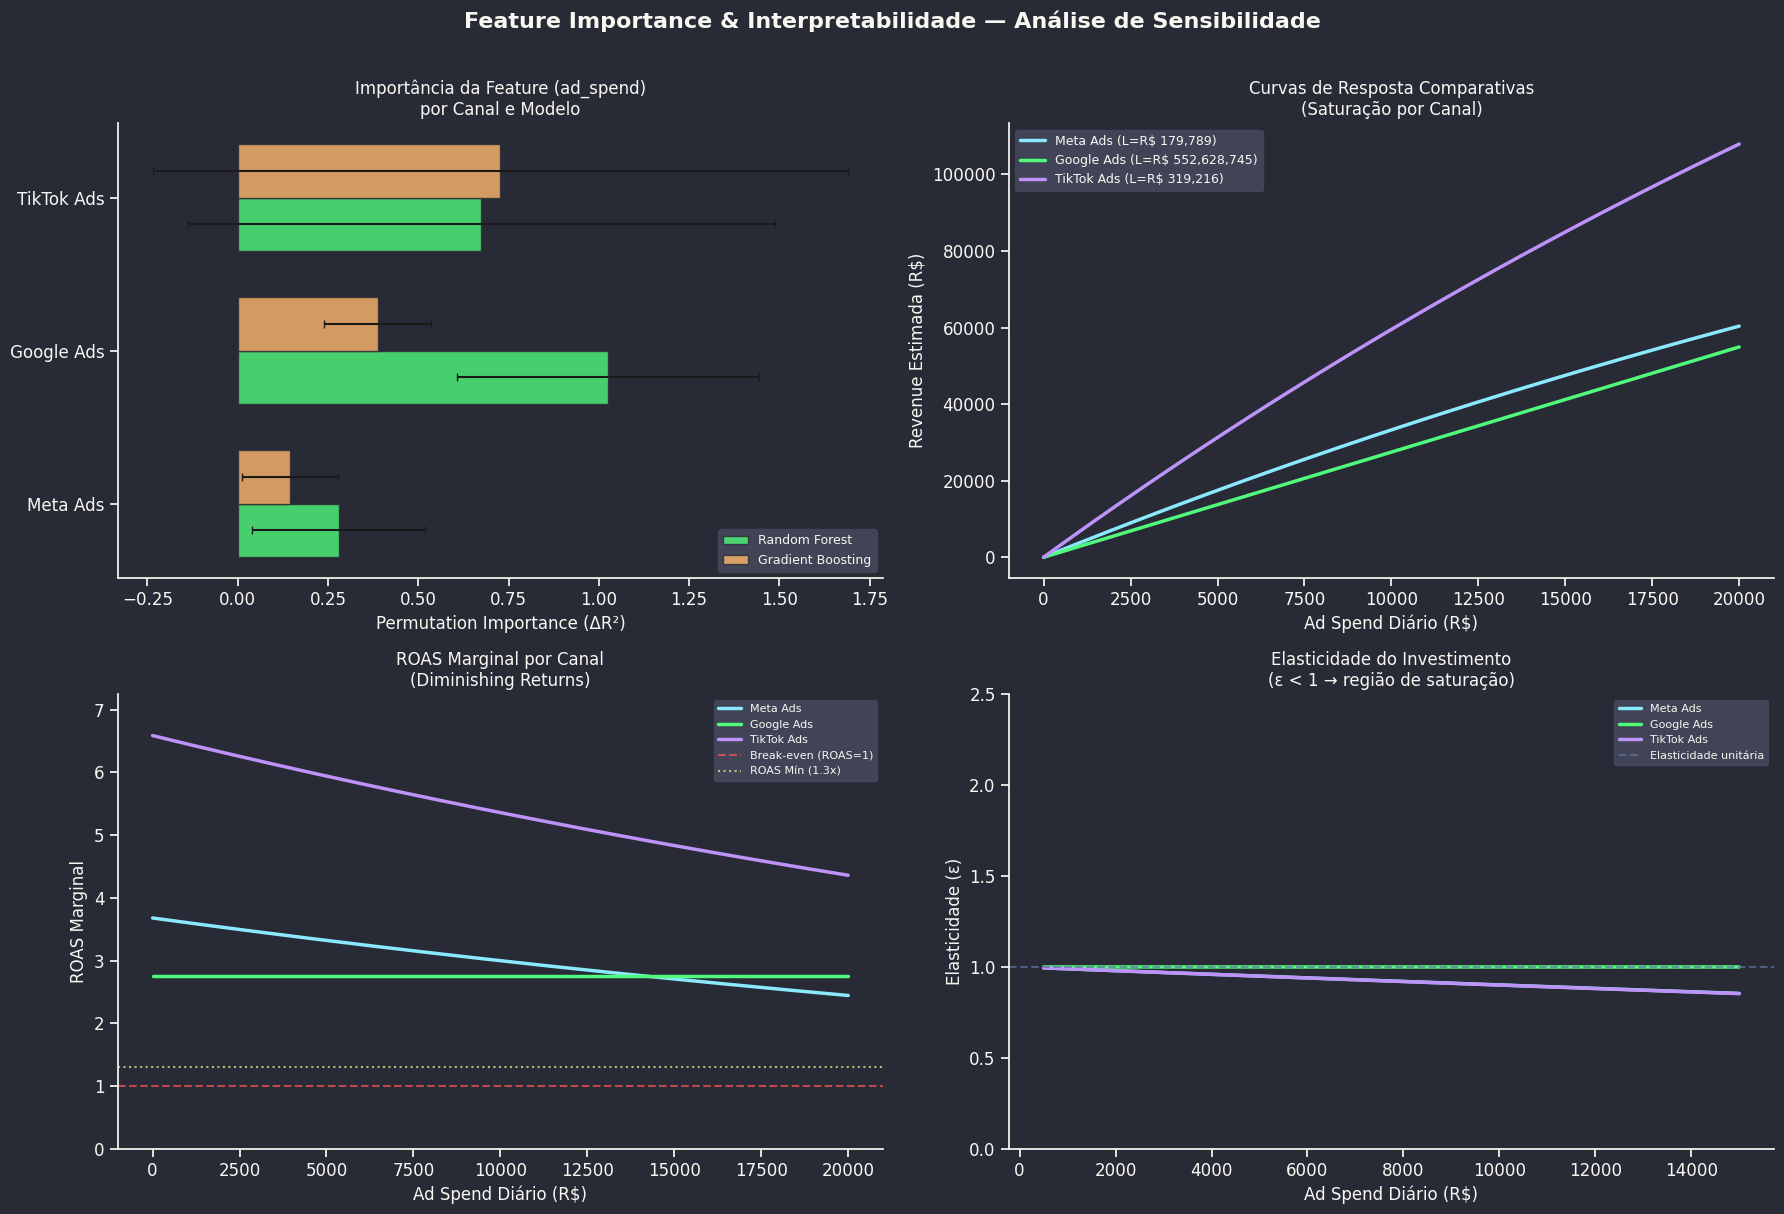


📊 RESUMO DE INTERPRETABILIDADE
   Meta Ads     → L = R$  179,789 | ROAS marginal @R$5k: 3.32x | Elast: 0.95
   Google Ads   → L = R$ 552,628,745 | ROAS marginal @R$5k: 2.75x | Elast: 1.00
   TikTok Ads   → L = R$  319,216 | ROAS marginal @R$5k: 5.94x | Elast: 0.95

📖 Interpretação da Elasticidade:
   • ε > 1: Investimento ainda não atingiu saturação (retorno crescente)
   • ε ≈ 1: Ponto de inflexão (retorno proporcional ao investimento)
   • ε < 1: Região de saturação (diminishing returns)


In [17]:
# === Feature Importance & Interpretabilidade ===

# Treinar modelos de saturação em train+val para análise de interpretabilidade
sat_models_interp = {}
for plat in platforms:
    d = data_by_platform[plat]
    sat = SaturationRegressor()
    X_full = np.vstack([d['X_train'], d['X_val']])
    y_full = np.concatenate([d['y_train'], d['y_val']])
    sat.fit(X_full, y_full)
    sat_models_interp[plat] = sat

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- 1. Permutation Importance (RF e GB tunados) ---
perm_results = []
for plat in platforms:
    d = data_by_platform[plat]
    for name in ['Random Forest', 'Gradient Boosting']:
        model = trained_models[plat][name]
        r = permutation_importance(model, d['X_test'], d['y_test'],
                                   n_repeats=30, random_state=SEED, scoring='r2')
        perm_results.append({
            'Plataforma': plat,
            'Modelo': name,
            'Importância Média': r.importances_mean[0],
            'Importância Std': r.importances_std[0],
        })

perm_df = pd.DataFrame(perm_results)
x_pos = np.arange(len(platforms))
width = 0.35

rf_imp = perm_df[perm_df['Modelo'] == 'Random Forest']['Importância Média'].values
gb_imp = perm_df[perm_df['Modelo'] == 'Gradient Boosting']['Importância Média'].values
rf_std = perm_df[perm_df['Modelo'] == 'Random Forest']['Importância Std'].values
gb_std = perm_df[perm_df['Modelo'] == 'Gradient Boosting']['Importância Std'].values

axes[0, 0].barh(x_pos - width/2, rf_imp, width, xerr=rf_std, label='Random Forest',
               color=DRACULA['green'], alpha=0.8, capsize=3, edgecolor=DRACULA['bg'])
axes[0, 0].barh(x_pos + width/2, gb_imp, width, xerr=gb_std, label='Gradient Boosting',
               color=DRACULA['orange'], alpha=0.8, capsize=3, edgecolor=DRACULA['bg'])
axes[0, 0].set_yticks(x_pos)
axes[0, 0].set_yticklabels(platforms)
axes[0, 0].set_xlabel('Permutation Importance (ΔR²)')
axes[0, 0].set_title('Importância da Feature (ad_spend)\npor Canal e Modelo', fontsize=12)
axes[0, 0].legend(fontsize=9)

# --- 2. Curvas de Resposta Comparativas (Saturação) ---
x_spend = np.linspace(0, 20000, 500)
for plat in platforms:
    sat = sat_models_interp[plat]
    y_pred = saturation_curve(x_spend, sat.L_, sat.k_)
    axes[0, 1].plot(x_spend, y_pred, linewidth=2.5, color=COLORS[plat],
                    label=f'{plat} (L=R$ {sat.L_:,.0f})')
axes[0, 1].set_xlabel('Ad Spend Diário (R$)')
axes[0, 1].set_ylabel('Revenue Estimada (R$)')
axes[0, 1].set_title('Curvas de Resposta Comparativas\n(Saturação por Canal)', fontsize=12)
axes[0, 1].legend(fontsize=9)

# --- 3. ROAS Marginal ---
max_mroas = 0
for plat in platforms:
    sat = sat_models_interp[plat]
    m_roas = marginal_roas(x_spend, sat.L_, sat.k_)
    max_mroas = max(max_mroas, m_roas.max())
    axes[1, 0].plot(x_spend, m_roas, linewidth=2.5, color=COLORS[plat], label=f'{plat}')

axes[1, 0].axhline(y=1.0, color=DRACULA['red'], linestyle='--', linewidth=1.5, alpha=0.7,
                    label='Break-even (ROAS=1)')
axes[1, 0].axhline(y=MIN_ROAS_GLOBAL, color=DRACULA['yellow'], linestyle=':', linewidth=1.5,
                    alpha=0.7, label=f'ROAS Mín ({MIN_ROAS_GLOBAL}x)')
axes[1, 0].set_xlabel('Ad Spend Diário (R$)')
axes[1, 0].set_ylabel('ROAS Marginal')
axes[1, 0].set_title('ROAS Marginal por Canal\n(Diminishing Returns)', fontsize=12)
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_ylim([0, min(max_mroas * 1.1, 20)])

# --- 4. Elasticidade do Investimento ---
spend_levels = np.linspace(500, 15000, 50)
for plat in platforms:
    sat = sat_models_interp[plat]
    rev_at_spend = saturation_curve(spend_levels, sat.L_, sat.k_)
    mroas_at_spend = marginal_roas(spend_levels, sat.L_, sat.k_)
    # Elasticidade: ε = (dRevenue/dSpend) × (Spend/Revenue)
    elasticity = mroas_at_spend * spend_levels / np.maximum(rev_at_spend, 1)
    axes[1, 1].plot(spend_levels, elasticity, linewidth=2.5, color=COLORS[plat], label=plat)

axes[1, 1].axhline(y=1.0, color=DRACULA['comment'], linestyle='--', linewidth=1.5, alpha=0.7,
                    label='Elasticidade unitária')
axes[1, 1].set_xlabel('Ad Spend Diário (R$)')
axes[1, 1].set_ylabel('Elasticidade (ε)')
axes[1, 1].set_title('Elasticidade do Investimento\n(ε < 1 → região de saturação)', fontsize=12)
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_ylim([0, 2.5])

plt.suptitle('Feature Importance & Interpretabilidade — Análise de Sensibilidade',
             fontsize=16, fontweight='bold', y=1.01, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

# Resumo
print("\n\U0001f4ca RESUMO DE INTERPRETABILIDADE")
print("=" * 70)
for plat in platforms:
    sat = sat_models_interp[plat]
    roas_5k = marginal_roas(5000, sat.L_, sat.k_)
    rev_5k = saturation_curve(5000, sat.L_, sat.k_)
    elast_5k = roas_5k * 5000 / max(rev_5k, 1)
    print(f"   {plat:12s} → L = R$ {sat.L_:>8,.0f} | ROAS marginal @R$5k: {roas_5k:.2f}x | Elast: {elast_5k:.2f}")

print("\n\U0001f4d6 Interpretação da Elasticidade:")
print("   • ε > 1: Investimento ainda não atingiu saturação (retorno crescente)")
print("   • ε ≈ 1: Ponto de inflexão (retorno proporcional ao investimento)")
print("   • ε < 1: Região de saturação (diminishing returns)")

<a id="12"></a>
## 12. Otimização de Portfólio — Fronteira Eficiente

> *"The whole point of the Machine Learning project is to use the model in production."* — Géron, Cap. 2

Utilizamos `scipy.optimize.minimize` (SLSQP) para encontrar a **alocação ótima** de budget entre os canais, usando as curvas de saturação calibradas como função-resposta.

### Formulação Matemática:
$$\max_{x} \sum_{c} L_c \cdot (1 - e^{-k_c \cdot x_c})$$

Sujeito a:
- $\sum x_c \leq B$ (budget total)
- $B \cdot s_{min} \leq x_c \leq B \cdot s_{max}$ (share por canal)
- $ROAS \geq ROAS_{min}$ (retorno mínimo)

In [18]:
# === Treinar modelos finais de saturação em treino+validação ===
final_sat_models = {}
for plat in platforms:
    d = data_by_platform[plat]
    X_final = np.vstack([d['X_train'], d['X_val']])
    y_final = np.concatenate([d['y_train'], d['y_val']])
    sat = SaturationRegressor()
    sat.fit(X_final, y_final)
    final_sat_models[plat] = sat
    print(f"   {plat:12s} → L = {sat.L_:,.2f}, k = {sat.k_:.6f}")

# Avaliar no conjunto de TESTE (nunca visto)
print("\n📊 Performance Final no Conjunto de TESTE (unseen data):")
print("─" * 60)
for plat in platforms:
    d = data_by_platform[plat]
    y_pred = np.maximum(final_sat_models[plat].predict(d['X_test']), 0)
    r2 = r2_score(d['y_test'], y_pred)
    rmse = np.sqrt(mean_squared_error(d['y_test'], y_pred))
    mape = mean_absolute_percentage_error(d['y_test'], y_pred) * 100
    print(f"   {plat:12s} → R² = {r2:.3f} | RMSE = {rmse:,.2f} | MAPE = {mape:.1f}%")

# === Otimização ===
channel_list = list(COLORS.keys())

def objective_function(allocation):
    total_rev = 0
    for i, plat in enumerate(channel_list):
        if plat in final_sat_models:
            total_rev += saturation_curve(allocation[i], final_sat_models[plat].L_, final_sat_models[plat].k_)
    return -total_rev

# Restrições de negócio
bounds_opt = tuple(
    (TOTAL_BUDGET * MIN_SHARE, TOTAL_BUDGET * MAX_SHARE) for _ in channel_list
)
constraints = [
    {'type': 'ineq', 'fun': lambda x: TOTAL_BUDGET - np.sum(x)},
    {'type': 'ineq', 'fun': lambda x: -objective_function(x) - MIN_ROAS_GLOBAL * np.sum(x)}
]
initial_guess = [TOTAL_BUDGET / len(channel_list)] * len(channel_list)

res = minimize(objective_function, initial_guess, method='SLSQP',
               bounds=bounds_opt, constraints=constraints)

if res.success:
    alloc = res.x
    spend = np.sum(alloc)
    rev = -res.fun
    roas = rev / spend if spend > 0 else 0

    print("\n" + "=" * 60)
    print("🎯 RECOMENDAÇÃO DO ALGORITMO — ALOCAÇÃO ÓTIMA")
    print("=" * 60)

    if spend < TOTAL_BUDGET - 1:
        print(f"⚠️  Para manter ROAS ≥ {MIN_ROAS_GLOBAL}x, reter parte da verba.")
        print(f"   Gastar R$ {spend:,.2f} dos R$ {TOTAL_BUDGET:,.2f}")
    else:
        print(f"✅ Budget totalmente alocado: R$ {TOTAL_BUDGET:,.2f}")

    print()
    for i, plat in enumerate(channel_list):
        pct = alloc[i] / spend * 100
        bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
        print(f"   {plat:12s}: R$ {alloc[i]:>10,.2f} ({pct:5.1f}%) {bar}")

    print(f"\n   {'─' * 58}")
    print(f"   {'TOTAL':12s}: R$ {spend:>10,.2f}")
    print(f"\n🏆 RECEITA ESTIMADA: R$ {rev:,.2f}")
    print(f"📈 ROAS ESTIMADO:   {roas:.2f}x")
    print("=" * 60)
else:
    print("\n❌ INVIÁVEL: Restrições de negócio impedem solução ótima.")
    print(f"   Relaxe ROAS mínimo ou limites de share.")


   Meta Ads     → L = 179,789.20, k = 0.000020
   Google Ads   → L = 552,628,745.36, k = 0.000000
   TikTok Ads   → L = 319,216.08, k = 0.000021

📊 Performance Final no Conjunto de TESTE (unseen data):
────────────────────────────────────────────────────────────
   Meta Ads     → R² = 0.078 | RMSE = 14,996.32 | MAPE = 101.8%
   Google Ads   → R² = 0.375 | RMSE = 23,166.88 | MAPE = 227.8%
   TikTok Ads   → R² = 0.095 | RMSE = 47,154.15 | MAPE = 166.3%

🎯 RECOMENDAÇÃO DO ALGORITMO — ALOCAÇÃO ÓTIMA
✅ Budget totalmente alocado: R$ 15,000.00

   Google Ads  : R$   2,733.75 ( 18.2%) █████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   Meta Ads    : R$   3,266.25 ( 21.8%) ██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
   TikTok Ads  : R$   9,000.00 ( 60.0%) ██████████████████████████████░░░░░░░░░░░░░░░░░░░░

   ──────────────────────────────────────────────────────────
   TOTAL       : R$  15,000.00

🏆 RECEITA ESTIMADA: R$ 73,230.90
📈 ROAS ESTIMADO:   4.88x


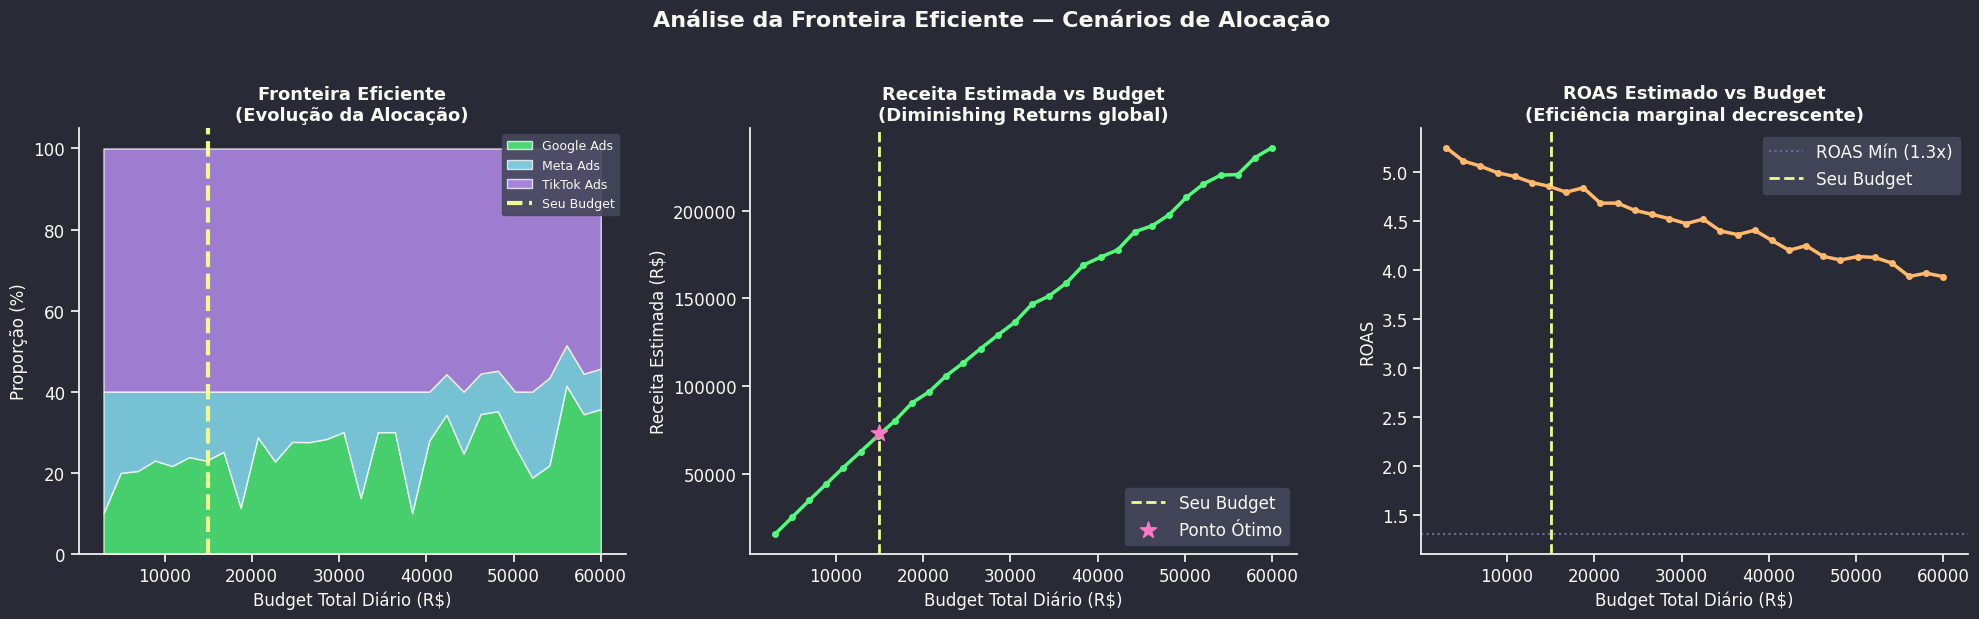

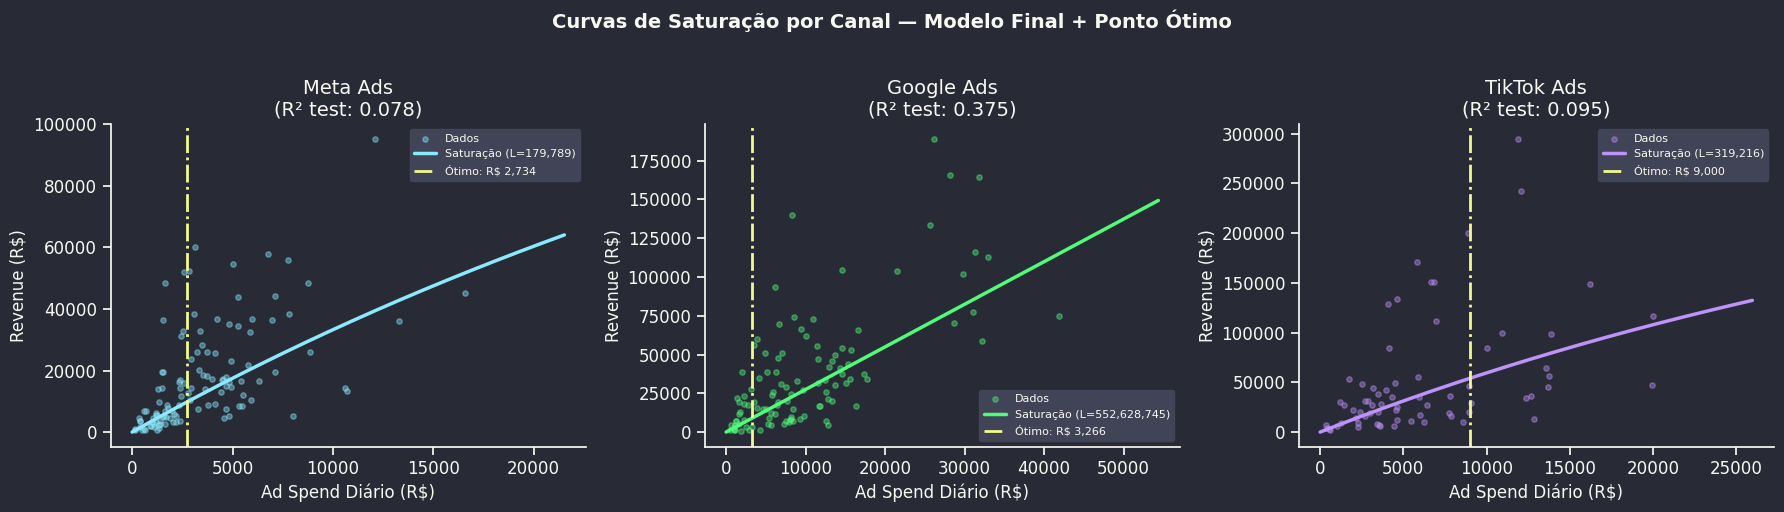

In [19]:
# === Fronteira Eficiente ===
budgets_range = np.linspace(3000, max(60000, TOTAL_BUDGET * 2), 30)
frontier_allocs = []
frontier_revs = []
frontier_roas = []

for b in budgets_range:
    bounds_ef = tuple((b * MIN_SHARE, b * MAX_SHARE) for _ in channel_list)
    cons_ef = [{'type': 'eq', 'fun': lambda x, b=b: b - np.sum(x)}]
    res_ef = minimize(objective_function, [b/3]*3, method='SLSQP', bounds=bounds_ef, constraints=cons_ef)
    frontier_allocs.append(res_ef.x)
    rev_ef = -res_ef.fun
    frontier_revs.append(rev_ef)
    frontier_roas.append(rev_ef / b if b > 0 else 0)

frontier_df = pd.DataFrame(frontier_allocs, columns=channel_list)
frontier_pct = frontier_df.div(budgets_range, axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Fronteira Eficiente (Alocação %)
axes[0].stackplot(
    budgets_range,
    frontier_pct['Google Ads'], frontier_pct['Meta Ads'], frontier_pct['TikTok Ads'],
    labels=channel_list,
    colors=[COLORS[c] for c in channel_list],
    alpha=0.8
)
if res.success:
    axes[0].axvline(x=TOTAL_BUDGET, color=DRACULA['yellow'], linestyle='--', linewidth=3, label='Seu Budget')
axes[0].set_title('Fronteira Eficiente\n(Evolução da Alocação)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Budget Total Diário (R$)')
axes[0].set_ylabel('Proporção (%)')
axes[0].legend(loc='upper right', fontsize=9)

# 2. Receita Estimada vs Budget
axes[1].plot(budgets_range, frontier_revs, color=DRACULA['green'], linewidth=2.5, marker='o', markersize=4)
if res.success:
    axes[1].axvline(x=TOTAL_BUDGET, color=DRACULA['yellow'], linestyle='--', linewidth=2, label='Seu Budget')
    axes[1].scatter([spend], [rev], color=DRACULA['pink'], s=150, zorder=5, marker='*', label='Ponto Ótimo')
axes[1].set_title('Receita Estimada vs Budget\n(Diminishing Returns global)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Budget Total Diário (R$)')
axes[1].set_ylabel('Receita Estimada (R$)')
axes[1].legend()

# 3. ROAS vs Budget
axes[2].plot(budgets_range, frontier_roas, color=DRACULA['orange'], linewidth=2.5, marker='o', markersize=4)
axes[2].axhline(y=MIN_ROAS_GLOBAL, color=DRACULA['comment'], linestyle=':', linewidth=1.5, label=f'ROAS Mín ({MIN_ROAS_GLOBAL}x)')
if res.success:
    axes[2].axvline(x=TOTAL_BUDGET, color=DRACULA['yellow'], linestyle='--', linewidth=2, label='Seu Budget')
axes[2].set_title('ROAS Estimado vs Budget\n(Eficiência marginal decrescente)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Budget Total Diário (R$)')
axes[2].set_ylabel('ROAS')
axes[2].legend()

plt.suptitle('Análise da Fronteira Eficiente — Cenários de Alocação',
             fontsize=16, fontweight='bold', y=1.03, color=DRACULA['fg'])
plt.tight_layout()
plt.show()

# Curvas de Saturação individuais
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, plat in enumerate(platforms):
    d = data_by_platform[plat]
    sat = final_sat_models[plat]

    # Plot todos os dados
    all_spend = d['full']['ad_spend'].values
    all_rev = d['full']['revenue'].values
    axes[i].scatter(all_spend, all_rev, color=COLORS[plat], alpha=0.4, s=15, label='Dados')

    # Curva ajustada
    x_plot = np.linspace(0, max(all_spend) * 1.3, 200)
    axes[i].plot(x_plot, saturation_curve(x_plot, sat.L_, sat.k_),
                 color=COLORS[plat], linewidth=2.5, label=f'Saturação (L={sat.L_:,.0f})')

    # ROAS marginal = 1 (break-even)
    m_roas = marginal_roas(x_plot, sat.L_, sat.k_)
    idx_be = np.argmin(np.abs(m_roas - 1.0))
    if m_roas[idx_be] < 1.5:
        axes[i].axvline(x=x_plot[idx_be], color=DRACULA['red'], linestyle='--', alpha=0.7,
                        label=f'Break-even (R$ {x_plot[idx_be]:,.0f})')

    # Alocação ótima
    if res.success:
        axes[i].axvline(x=alloc[i], color=DRACULA['yellow'], linewidth=2, linestyle='-.',
                        label=f'Ótimo: R$ {alloc[i]:,.0f}')

    axes[i].set_title(f'{plat}\n(R² test: {r2_score(d["y_test"], np.maximum(sat.predict(d["X_test"]), 0)):.3f})')
    axes[i].set_xlabel('Ad Spend Diário (R$)')
    axes[i].set_ylabel('Revenue (R$)')
    axes[i].legend(fontsize=8)

plt.suptitle('Curvas de Saturação por Canal — Modelo Final + Ponto Ótimo',
             fontsize=14, fontweight='bold', y=1.02, color=DRACULA['fg'])
plt.tight_layout()
plt.show()


<a id="13"></a>
## 13. Conclusão e Próximos Passos

### 13.1 Resumo Executivo

Este projeto implementou um **pipeline completo de Machine Learning** para otimização de budget de marketing digital, seguindo a metodologia do livro *Hands-On Machine Learning* (Aurélien Géron):

1. ✅ **6 modelos** comparados (Baseline, Linear, Polynomial, Random Forest, Gradient Boosting, Saturação)
2. ✅ **Cross-validation temporal** com `TimeSeriesSplit` (sem data leakage)
3. ✅ **Custom Transformers** integrados ao scikit-learn (Adstock, Log)
4. ✅ **Hyperparameter Tuning** com `GridSearchCV` + `TimeSeriesSplit`
5. ✅ **Learning Curves** para diagnóstico de bias/variância
6. ✅ **Feature Importance** com permutation importance e análise de elasticidade
7. ✅ **Análise de resíduos** completa (QQ-plots, predicted vs actual)
8. ✅ **Otimização restrita** com Fronteira Eficiente
9. ✅ **Reprodutibilidade** total (seeds, hash, versões)

### 13.2 Limitações

> *"No model is perfect. Always discuss the limitations."* — Géron

- **Dados simulados**: O dataset é sintético. Em produção, usar dados reais com maior granularidade
- **Independência de canais**: Modelamos canais individualmente; um modelo multivariado (MMM bayesiano) capturaria interações
- **Estacionariedade**: Assumimos padrões estáveis; em cenários reais, retreinar periodicamente
- **Ausência de variáveis externas**: Sazonalidade, concorrência e macroeconomia não estão no modelo
- **Feature única**: O modelo usa apenas `ad_spend` por canal; adicionar features como CTR, CPC, impressões melhoraria a predição

### 13.3 Próximos Passos

| Prioridade | Ação | Referência |
|-----------|------|------------|
| 🔴 Alta | Teste de Incrementalidade (Lift Test geográfico) | Brown (2023) |
| 🟡 Média | MMM Bayesiano (PyMC-Marketing ou LightweightMMM) | Géron Cap. 9-11 |
| 🟡 Média | Adicionar variáveis de sazonalidade e macro | Géron Cap. 2 |
| 🟡 Média | SHAP values para interpretabilidade avançada | Linoff (2011) |
| 🟢 Baixa | Deploy como API REST (FastAPI + Docker) | Géron Cap. 2 (Launch) |
| 🟢 Baixa | Dashboard interativo (Streamlit) | — |

### 13.4 Referências Bibliográficas

1. Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. 3rd Ed. O'Reilly.
2. Linoff, G. S. & Berry, M. J. (2011). *Data Mining Techniques*. 3rd Ed. Wiley.
3. Brown, I. (2023). *Mastering Marketing Data Science*. Packt.
4. Miller, T. (2015). *Modeling Techniques in Predictive Analytics with Python and R*. Pearson.

<a id="14"></a>
## 14. Persistência do Modelo e Experiment Tracking

> *"You should save every model you experiment with, so that you can come back easily to any model you want."* — Géron

Nesta etapa final focada em **MLOps**:
1. **Pipeline End-to-End**: Englobamos o `AdstockTransformer` e o `SaturationRegressor` dentro de um `sklearn.pipeline.Pipeline`. O artefato final salvo receberá o dado bruto de investimento e já retornará a predição.
2. **Experiment Tracking**: Salvamos um artefato `metrics.json` contendo hiperparâmetros treinados, resultados de $R^2$ e alocações otimizadas para monitoramento contínuo da saúde do modelo em produção.

In [20]:
# === Salvar modelos, parâmetros da otimização e MÉTRICAS ===
import os
import json
import time
import joblib
from sklearn.pipeline import Pipeline

os.makedirs('models', exist_ok=True)

# 1. Montar e salvar Pipeline End-to-End
# O Pipeline engloba o Adstock (transformação temporal) e o Modelo de Saturação
for plat, model in final_sat_models.items():
    # Cria o pipeline completo
    end_to_end_pipe = Pipeline([
        ('adstock', AdstockTransformer(decay_rate=0.3)),
        ('model', model)
    ])
    
    filename = f"models/pipeline_{plat.replace(' ', '_').lower()}.joblib"
    joblib.dump(end_to_end_pipe, filename)
    print(f"💾 Pipeline Salvo: {filename}")

# 2. Salvar resultado da otimização (joblib e json)
opt_result = {
    'budget_total': TOTAL_BUDGET,
    'min_roas': MIN_ROAS_GLOBAL,
    'allocation': dict(zip(channel_list, alloc.tolist())) if res.success else None,
    'estimated_revenue': rev if res.success else None,
    'estimated_roas': roas if res.success else None,
    'success': res.success,
}
joblib.dump(opt_result, 'models/optimization_result.joblib')

# 3. Experiment Tracking: Salvar métricas de performance e parâmetros
metrics_dict = {
    'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'optimization': opt_result,
    'channels': {}
}

for plat in platforms:
    d = data_by_platform[plat]
    # Avaliar o modelo final no teste para registrar as métricas
    y_pred = np.maximum(final_sat_models[plat].predict(d['X_test']), 0)
    r2 = r2_score(d['y_test'], y_pred)
    rmse = np.sqrt(mean_squared_error(d['y_test'], y_pred))
    
    metrics_dict['channels'][plat] = {
        'r2_test': r2,
        'rmse_test': rmse,
        'saturation_params': {
            'L': final_sat_models[plat].L_,
            'k': final_sat_models[plat].k_
        }
    }

with open('models/metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print("💾 Métricas e Tracking Salvos: models/metrics.json")

# Função de predição para uso futuro usando os PIPELINES
def predict_revenue(spend_dict):
    """
    Prediz a receita total dada uma alocação de budget usando Pipelines End-to-End.
    """
    result = {}
    total = 0
    for plat, spend in spend_dict.items():
        filename = f"models/pipeline_{plat.replace(' ', '_').lower()}.joblib"
        if os.path.exists(filename):
            pipe = joblib.load(filename)
            # O Pipeline recebe os dados 'crus' de investimento. 
            # Em inferência de 1 dia, passamos um array de 1 elemento.
            # O Adstock irá tratar como um pico de investimento isolado.
            X_input = np.array([spend])
            rev = pipe.predict(X_input)[0]
            result[plat] = round(rev, 2)
            total += rev
            
    result['TOTAL'] = round(total, 2)
    result['ROAS'] = round(total / sum(spend_dict.values()), 2) if sum(spend_dict.values()) > 0 else 0
    return result

# Demo
demo = predict_revenue({'Google Ads': 5000, 'Meta Ads': 5000, 'TikTok Ads': 5000})
print("\n🔮 Demo API/Pipeline — predict_revenue({Google: 5000, Meta: 5000, TikTok: 5000}):")
for k, v in demo.items():
    if k in ['TOTAL', 'ROAS']:
        print(f"   {'─' * 35}")
    prefix = "R$" if k != 'ROAS' else ""
    suffix = "x" if k == 'ROAS' else ""
    print(f"   {k:12s}: {prefix} {v:>10,.2f}{suffix}")

print("\n✅ Pipeline End-to-End completo e Métricas Salvas em /models/")

💾 Pipeline Salvo: models/pipeline_meta_ads.joblib
💾 Pipeline Salvo: models/pipeline_google_ads.joblib
💾 Pipeline Salvo: models/pipeline_tiktok_ads.joblib
💾 Métricas e Tracking Salvos: models/metrics.json

🔮 Demo API/Pipeline — predict_revenue({Google: 5000, Meta: 5000, TikTok: 5000}):
   Google Ads  : R$  13,733.63
   Meta Ads    : R$  17,483.32
   TikTok Ads  : R$  31,290.43
   ───────────────────────────────────
   TOTAL       : R$  62,507.39
   ───────────────────────────────────
   ROAS        :        4.17x

✅ Pipeline End-to-End completo e Métricas Salvas em /models/
